In [1]:
from pathlib import Path
import pandas as pd
from timesnet_encoder import TimesBlock
from sequences_peaks import SequenceConfig, _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask, TrainSequence, ValidationSequence, _wavelet_filter
from dataclasses import replace
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)


I0000 00:00:1779085532.928817   44743 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import os
from datetime import datetime

# Klasör ismini bugünün tarihiyle oluştur
date_str = datetime.now().strftime("%Y%m%d")
MODEL_FOLDER = f"{date_str}-GAN-v4.7"

# Klasörleri yarat
os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(f"{MODEL_FOLDER}/weights", exist_ok=True) # Ağırlıklar buraya

# description.txt dosyasını oluştur ve yaz
description_text = """
MODEL VERSİYONU: GAN v4.7 (Gaussian Dynamic Masking & Randomized Eraser / SOTA Referanslı GAN)
LOSS OF STFT ADDED.
MİMARİ ÖZETİ VE "DİNAMİK KÖRLEŞTİRME" MANTIĞI:
1. ENCODER (Stil Çıkarıcı): 
   - Girdi: [Rastgele Körleştirilmiş Sinyal (Z-Score), Gaussian Peak Maskesi]
   - Latent Boyutu: 512'den 128'e düşürülerek bilgi darboğazı (bottleneck) daraltıldı. Modelin arka plandaki gereksiz detayları ezberlemesi engellendi, sadece saf "Stil DNA'sı"na odaklanması sağlandı.
   - Latent Noise: Encoder'dan çıkan 128 boyutlu DNA'ya eğitim sırasında suni gürültü (std=0.1) eklenerek Latent Space (Gizli Uzay) pürüzsüzleştirildi. Jeneratörün ezberciliği kırıldı.
   - KRİTİK GÜNCELLEME (Randomized Eraser): Sabit boyutlu (61 birimlik) silgi mantığı tamamen terk edildi. Bunun yerine, adım şablonunun sağından ve solundan rastgele (20-80 birim) taşan, her iterasyonda boyutu dinamik olarak değişen "Rastgele Dev Silgi (enc_mask)" DataLoader içerisine entegre edildi. Modelin boşluğu ezberleme (leakage) ihtimali sıfırlandı.

2. GENERATOR (Sentezleyici):
   - Girdi: [Gürültülü z_encoded (Stil DNA'sı), Gaussian Peak Maskesi (Şablon)]
   - Görevi: Hedef şablona bakarak yürüme adımını dinamik olarak sentezlemek ve arka planla kaynaştırmak.
   - KRİTİK GÜNCELLEME (Soft Gaussian Masking): Hedef şablon (peak_mask) artık sert kenarlı (binary) kutular yerine, merkeze doğru güçlenen ve uçlara doğru yumuşakça sönen bir Çan Eğrisi (Gaussian Window) olarak veriliyor. Bu sayede Jeneratör, ürettiği adımı sessizliğe "fade-in/fade-out" yaparak pürüzsüzce yedirmeyi öğreniyor, sert sınırların yarattığı yapay iğne zıplamaları (artifacts) engelleniyor.
   - Dynamic Physical Loss: Fiziksel kurallar (L_amp, L_energy, L_grad) doğrudan bu yumuşak Gaussian maskenin sınırları içine uygulanıyor. Maske merkezinde enerji tavan yaparken, maske sönümlendikçe enerji doğal bir şekilde (ring-down) azalıyor.

3. DISCRIMINATOR (Koşullu Hakem):
   - Girdi: [Tam Sinyal + Instance Noise (std=0.05), Gaussian Peak Maskesi]
   - Görevi: Sinyalin gerçekçi bir sismik titreşim olup olmadığını ve yumuşak maskeyle uyumunu denetlemek. 
   - Savunmalar: TTUR (Farklı öğrenme hızları) ve Label Smoothing (0.9 / 0.1) aktif olarak Hakemin Jeneratörü ezmesini engelliyor.

VERİ VE MİMARİ FELSEFESİ:
- Karmaşık, birbiriyle çelişen fiziksel kısıtlamalar terk edilerek "KISS (Keep It Simple, Stupid)" mühendislik felsefesine geçildi.
- Kopya çekmeyi önleyen dev silgi (enc_mask) ile hedefi gösteren şablon (peak_mask), modelin içine girmeden önce DataLoader seviyesinde (NumPy ile) ayrıştırıldı. TensorFlow Graph'ının üzerindeki karmaşık operasyon yükü kaldırıldı.
- Sinyal sentezlemesinde kutu gibi (square) maskeler yerine, doğadaki akustik seslerin sönümlenme fiziğine birebir uygun olan yumuşak zarflar (envelope/Gaussian) standart haline getirildi.
"""

with open(os.path.join(MODEL_FOLDER, "description.txt"), "w", encoding="utf-8") as f:
    f.write(description_text.strip())
    
print(f"Klasör ve Açıklama Dosyası Hazır: {MODEL_FOLDER}")

Klasör ve Açıklama Dosyası Hazır: 20260518-GAN-v4.7


In [3]:

DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = "train_all_peaks.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"

WINDOW_SIZE = 5000
LABEL_NAMES = ['walking']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=32,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

In [4]:
encoder = TimesBlock.build_encoder_v4(latent_dim=128)
generator = TimesBlock.build_generator_v4(latent_dim=128)
discriminator = TimesBlock.build_discriminator_v4_1()

encoder.summary()
generator.summary()
discriminator.summary()

I0000 00:00:1779085537.080485   44743 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13505 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "Encoder_V4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_input_only (InputLayer)  │ (None, 5000, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 625, 64)        │         5,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 625, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ times_block (TimesBlock)        │ (None, 625, 64)        │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ times_block_1 (TimesBlock)      │ (None, 625, 64)        │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │         8,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,112 (633.25 KB)

 Trainable params: 161,728 (631.75 KB)

...

Model: "Discriminator_V4_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ disc_input (InputLayer)         │ (None, 5000, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1250, 64)       │         5,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 1250, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1250, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ times_block_5 (TimesBlock)      │ (None, 1250, 64)       │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 313, 128)       │       172,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 313, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 313, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 313, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 79, 256)        │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 79, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 79, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ real_fake_score (Dense)         │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 630,337 (2.40 MB)

 Trainable params: 629,441 (2.40 MB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
import tensorflow as tf
# import tf_keras as keras
import tf_keras as legacy_keras
classifier = legacy_keras.models.load_model("/tf/models/clf939.h5")
classifier.trainable = False
WALKING_INDEX = 6

In [6]:
def prepare_for_classifier(fake_signals):
    # 1. Kanal boyutunu kaldır: (Batch, 5000, 1) -> (Batch, 5000)
    s = tf.squeeze(fake_signals, axis=-1)
    
    # 2. [1, 4] -> Zaman boyutunu 4 kez tekrarla (20.000 boyutuna ulaştır)
    s_20k = tf.tile(s, [1, 4])
    
    return s_20k

In [7]:
# Optimizer'lar
enc_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, clipnorm=1.0)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.5, clipnorm=1.0)

# Kayıp fonksiyonları
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()

# coefficients

alpha = 1.0 
beta = 0.5

In [8]:
def compute_stft_loss(real_sig, fake_sig, frame_length=256, frame_step=64):
    """
    Sinyallerin frekans (spektrogram) imzalarının ne kadar benzediğini hesaplar.
    Hem doğrusal genlikleri hem de logaritmik (desibel benzeri) düşük enerjileri kıyaslar.
    """
    # Girdiler (Batch, Window, 1) şeklindeyse son boyutu ezelim: (Batch, Window)
    real_sig = tf.squeeze(real_sig, axis=-1)
    fake_sig = tf.squeeze(fake_sig, axis=-1)
    
    # STFT Hesaplaması (TensorFlow'un yerleşik fonksiyonu)
    stft_real = tf.signal.stft(real_sig, frame_length=frame_length, frame_step=frame_step)
    stft_fake = tf.signal.stft(fake_sig, frame_length=frame_length, frame_step=frame_step)
    
    # Sadece büyüklükleri (Magnitude) al (Faz bilgisini çöpe atıyoruz)
    mag_real = tf.abs(stft_real)
    mag_fake = tf.abs(stft_fake)
    
    # Log-Magnitude (Düşük sönümlenme frekanslarındaki detayları kaybetmemek için)
    # log(0) hatası almamak için çok küçük bir epsilon (1e-7) ekliyoruz.
    log_mag_real = tf.math.log(mag_real + 1e-7)
    log_mag_fake = tf.math.log(mag_fake + 1e-7)
    
    # Hem güçlü vuruşlar (Linear Loss) hem de zayıf yankılar (Log Loss) için MAE (L1) hesabı
    lin_loss = tf.reduce_mean(tf.abs(mag_real - mag_fake))
    log_loss = tf.reduce_mean(tf.abs(log_mag_real - log_mag_fake))
    
    # İkisini toplayıp gönder
    return lin_loss + log_loss

In [9]:
import tensorflow as tf

@tf.function
def train_step(real_signals, peak_masks, enc_masks):
    batch_size = tf.shape(real_signals)[0]
    WALKING_INDEX = 6
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = tf.reduce_mean(real_signals, axis=1, keepdims=True)
    std = tf.math.reduce_std(real_signals, axis=1, keepdims=True) + 1e-8
    real_signals_normalized = (real_signals - mean) / std
    
    # 1. ENCODER İÇİN KÖRLEŞTİRME (Kopya çekmesin diye yine devasa 61 birimlik silgi kullanıyoruz)
    # expanded_masks_for_encoder = tf.nn.max_pool1d(peak_masks, ksize=61, strides=1, padding='SAME')
    inv_masks = 1.0 - enc_masks
    masked_real_signals = real_signals_normalized * inv_masks
    
    concat_input = tf.concat([masked_real_signals, peak_masks], axis=-1)
    real_for_disc = tf.concat([real_signals_normalized, peak_masks], axis=-1)

    # --- DISCRIMINATOR EĞİTİMİ ---
    with tf.GradientTape() as disc_tape:
        z_encoded = encoder(concat_input, training=False)
        z_noise = tf.random.normal(shape=tf.shape(z_encoded), mean=0.0, stddev=0.1)
        z_encoded_noisy = z_encoded + z_noise
        
        fake_signals = generator([z_encoded_noisy, peak_masks], training=False)
        fake_concat = tf.concat([fake_signals, peak_masks], axis=-1)
        
        noise_real = tf.random.normal(tf.shape(real_for_disc), mean=0.0, stddev=0.05)
        noise_fake = tf.random.normal(tf.shape(fake_concat), mean=0.0, stddev=0.05)
        
        pred_real = discriminator(real_for_disc + noise_real, training=True)
        pred_fake = discriminator(fake_concat + noise_fake, training=True)
        
        real_labels = tf.ones_like(pred_real) * 0.9
        fake_labels = tf.zeros_like(pred_fake) + 0.1
        
        d_loss = bce(real_labels, pred_real) + bce(fake_labels, pred_fake)

    grads_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(grads_disc, discriminator.trainable_variables))

    # --- ENCODER & GENERATOR EĞİTİMİ ---
    with tf.GradientTape() as gen_tape:
        z_encoded = encoder(concat_input, training=True)
        z_noise = tf.random.normal(shape=tf.shape(z_encoded), mean=0.0, stddev=0.1)
        z_encoded_noisy = z_encoded + z_noise
        
        fake_signals = generator([z_encoded_noisy, peak_masks], training=True)
        fake_concat = tf.concat([fake_signals, peak_masks], axis=-1)
        
        pred_fake_disc = discriminator(fake_concat, training=False)
        l_adv = bce(tf.ones_like(pred_fake_disc), pred_fake_disc)
        
        # +++ İŞTE SİHİR BURADA: Fiziksel kurallar SADECE DataLoader'dan gelen RANDOM maskeye (peak_masks) uygulanıyor +++
        real_masked = real_signals_normalized * peak_masks
        fake_masked = fake_signals * peak_masks
        
        # 1. MSE İkiye Bölündü
        bg_mask = 1.0 - peak_masks
        l_mse_bg = tf.reduce_mean(tf.square((real_signals_normalized - fake_signals) * bg_mask))
        l_mse_peak = tf.reduce_mean(tf.square((real_signals_normalized - fake_signals) * peak_masks))
        
        # --- 2. YÜKSEKLİK (Max Amp) ---
        real_max_amp = tf.reduce_max(tf.abs(real_masked), axis=1)
        fake_max_amp = tf.reduce_max(tf.abs(fake_masked), axis=1)
        l_amp = tf.reduce_mean(tf.abs(real_max_amp - fake_max_amp))
        
        # --- 3. YENİ: ENERJİ ZARFI (POWER ENVELOPE) - DEPREM ENGELLEYİCİ ---
        # Sinyalin karesini alarak gücünü bul
        real_power = tf.square(real_masked)
        fake_power = tf.square(fake_masked)
        
        # 9 birimlik hareketli pencerelerle enerjinin zaman içindeki "dağılım şeklini" (zarfını) çıkar
        real_env = tf.nn.avg_pool1d(real_power, ksize=9, strides=1, padding='SAME')
        fake_env = tf.nn.avg_pool1d(fake_power, ksize=9, strides=1, padding='SAME')
        
        # Enerjiyi toplam bir sayı olarak değil, ŞEKİL olarak tutturmaya zorla!
        # Jeneratör enerjiyi deprem gibi yayarsa şekil uymayacağı için devasa ceza yer.
        l_energy = tf.reduce_mean(tf.abs(real_env - fake_env))
        
        # --- 4. KIVRIM (Grad) ---
        real_grad = real_signals_normalized[:, 1:, :] - real_signals_normalized[:, :-1, :]
        fake_grad = fake_signals[:, 1:, :] - fake_signals[:, :-1, :]
        mask_for_grad = peak_masks[:, 1:, :]
        
        masked_real_grad = real_grad * mask_for_grad
        masked_fake_grad = fake_grad * mask_for_grad
        l_grad = tf.reduce_mean(tf.square(masked_real_grad - masked_fake_grad))
        l_stft = compute_stft_loss(real_signals_normalized, fake_signals)
        lambda_stft = 2.0
        # ANAYASA (Ağırlıklar korundu)
        L_rec = (l_adv + 
             (10.0 * l_mse_bg) + 
             (1.0 * l_mse_peak) + 
             (10.0 * l_amp) + 
             (10.0 * l_energy) + 
             (0.5 * l_grad) + 
             (lambda_stft * l_stft))
        # +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
        
        fake_20k = prepare_for_classifier(fake_signals) 
        cls_predictions = classifier(fake_20k, training=False)
        walking_scores = cls_predictions[:, WALKING_INDEX]
        L_cls = bce(tf.ones((batch_size,)), walking_scores)
        
        total_gen_loss = (alpha * L_rec) + (beta * L_cls)

    var_list = encoder.trainable_variables + generator.trainable_variables
    grads_gen = gen_tape.gradient(total_gen_loss, var_list)
    enc_gen_optimizer.apply_gradients(zip(grads_gen, var_list))
    
    return d_loss, total_gen_loss, L_rec, L_cls

In [10]:
# import matplotlib.pyplot as plt
# import numpy as np
# import os
# import tensorflow as tf

# def visualize_epoch_results(epoch, encoder, generator, train_seq, folder_path):
#     # Rastgele bir batch seç
#     batch_idx = np.random.randint(0, len(train_seq))
#     batch_data, _ = train_seq[batch_idx]
    
#     real_sig = batch_data[0:1, :, 0:1] 
#     peak_mask = batch_data[0:1, :, 1:2] # DataLoader'dan gelen RANDOM genişlikteki maske
    
#     # --- Z-SCORE NORMALİZASYONU ---
#     mean = np.mean(real_sig, axis=1, keepdims=True)
#     std = np.std(real_sig, axis=1, keepdims=True) + 1e-8
#     real_sig_norm = (real_sig - mean) / std 
    
#     # --- KÖRLEŞTİRME (Artık ksize=61 falan yok, maske neyse o kadar silinir) ---
#     peak_mask_np = peak_mask if isinstance(peak_mask, np.ndarray) else peak_mask.numpy()
#     inv_mask = 1.0 - peak_mask_np
#     masked_real_sig = real_sig_norm * inv_mask
    
#     # Encoder'a birleştirip ver
#     encoder_input = tf.concat([masked_real_sig, peak_mask], axis=-1)
    
#     # Inference (Çizim) sırasında noise eklemiyoruz ki saf stili görelim
#     z_encoded = encoder(encoder_input, training=False)
#     fake_sig_norm = generator([z_encoded, peak_mask], training=False)

#     # Vitrin Temizliği (Wavelet Denoising)
#     real_1d = real_sig_norm[0, :, 0]
#     fake_1d = fake_sig_norm[0, :, 0].numpy()
    
#     real_denoised = _wavelet_filter(real_1d)
#     fake_denoised = _wavelet_filter(fake_1d)
    
#     # --- ÇİZİM BÖLÜMÜ ---
#     plt.figure(figsize=(18, 10), dpi=90) 
    
#     # Üst Panel (Orijinal)
#     plt.subplot(2, 1, 1)
#     plt.plot(real_denoised, color='gray', alpha=0.8, label='Orijinal Sinyal (Denoised)')
    
#     # TEK MASKEYİ ÇİZ (O anki random genişlik)
#     plt.fill_between(range(5000), peak_mask_np[0, :, 0] * np.max(real_denoised), 
#                      color='red', alpha=0.2, label='Random Peak Alanı (Körleştirilen Kısım)')
                     
#     plt.title(f"Epoch {epoch+1}: Orijinal Veri (Denoised) ve Dinamik Maske Referansı")
#     plt.legend(loc='upper right')
#     plt.grid(True, alpha=0.3)
    
#     # Alt Panel (Yapay)
#     plt.subplot(2, 1, 2)
#     plt.plot(fake_denoised, color='dodgerblue', linewidth=1.2, label='AI Üretimi Sinyal (Denoised)')
    
#     # TEK MASKEYİ ÇİZ (Jeneratörün o maskenin içini nasıl doldurduğunu görmek için)
#     plt.fill_between(range(5000), peak_mask_np[0, :, 0] * np.max(fake_denoised), 
#                      color='red', alpha=0.2, label='Jeneratörün Enerji/Genlik Hedefi')
                     
#     plt.title(f"Epoch {epoch+1}: Jeneratör Çıktısının Temizlenmiş (Denoised) Hali")
#     plt.xlabel("Sample Index (5000)")
#     plt.legend(loc='upper right')
#     plt.grid(True, alpha=0.3)
    
#     plt.tight_layout(pad=2.0)
    
#     # Görseli belirlenen klasöre kaydet
#     save_path = os.path.join(folder_path, f"epoch_{epoch+1}_sonucu.png")
#     plt.savefig(save_path, bbox_inches='tight')
#     plt.show()
#     plt.close()

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import librosa
import librosa.display
from scipy import signal

def visualize_epoch_results(epoch, encoder, generator, train_seq, folder_path, sr=2000):
    """
    sr (Sample Rate): DAS verinin örnekleme frekansı. Örn: 1000 Hz, 2000 Hz. 
    """
    # Rastgele bir batch seç
    batch_idx = np.random.randint(0, len(train_seq))
    batch_data, _ = train_seq[batch_idx]
    
    real_sig = batch_data[0:1, :, 0:1] 
    peak_mask = batch_data[0:1, :, 1:2]
    window_size = real_sig.shape[1] # Örneğin 5000 veya 10000
    
    # +++ YENİ: SANİYE CİNSİNDEN ZAMAN EKSENİ (X-AXIS) OLUŞTURMA +++
    # Örneğin 5000 örnek, SR=2000 ise -> 2.5 saniyelik bir zaman dizisi oluşturur.
    time_axis = np.arange(window_size) / sr
    max_time = time_axis[-1] # Grafikleri hizalamak için sınır değeri
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = np.mean(real_sig, axis=1, keepdims=True)
    std = np.std(real_sig, axis=1, keepdims=True) + 1e-8
    real_sig_norm = (real_sig - mean) / std 
    
    # --- KÖRLEŞTİRME ---
    peak_mask_np = peak_mask if isinstance(peak_mask, np.ndarray) else peak_mask.numpy()
    inv_mask = 1.0 - peak_mask_np
    masked_real_sig = real_sig_norm * inv_mask
    
    # Encoder Girdisi ve Tensor Dönüşümü
    encoder_input = tf.concat([masked_real_sig, peak_mask], axis=-1)
    peak_mask_tf = tf.convert_to_tensor(peak_mask, dtype=tf.float32)
    
    # Inference
    z_encoded = encoder(encoder_input, training=False)
    fake_sig_norm = generator([z_encoded, peak_mask_tf], training=False)

    # 1B Formatına Çevir
    real_1d = real_sig_norm[0, :, 0]
    fake_1d = fake_sig_norm[0, :, 0].numpy()
    
    # FİLTRELEME (EKSEN KAYMASI VE DC OFFSET TEMİZLİĞİ)
    real_1d = signal.detrend(real_1d)
    fake_1d = signal.detrend(fake_1d)
    
    # sos = signal.butter(4, 5, 'hp', fs=sr, output='sos') 
    # real_1d = signal.sosfiltfilt(sos, real_1d)
    # fake_1d = signal.sosfiltfilt(sos, fake_1d)
    
    # # Vitrin Temizliği (Wavelet Denoising)
    # real_denoised = _wavelet_filter(real_1d)
    # fake_denoised = _wavelet_filter(fake_1d)
    
    # YÜKSEK ÇÖZÜNÜRLÜKLÜ SPEKTROGRAM AYARLARI
    HOP_LENGTH = 64
    N_FFT = 256
    FMIN = 10
    FMAX = sr // 2  
    DB_MIN = -50
    
    # ==========================================
    # --- ÇİZİM BÖLÜMÜ (4 PANEL: ZAMAN + FREKANS) ---
    # ==========================================
    plt.figure(figsize=(18, 16), dpi=90) 
    
    # 1. PANEL: Orijinal Waveform
    plt.subplot(4, 1, 1)
    # x ekseni olarak "time_axis" kullanıyoruz
    plt.plot(time_axis, real_1d, color='gray', alpha=0.8, label='Orijinal Sinyal (Waveform)')
    plt.fill_between(time_axis, peak_mask_np[0, :, 0] * np.max(np.abs(real_1d)), 
                     color='red', alpha=0.2, label='Random Peak Alanı')
    plt.xlim([0, max_time]) # Tam hizalama için sınır
    plt.title(f"Epoch {epoch+1}: Orijinal Waveform (SR: {sr} Hz)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # 2. PANEL: Orijinal Mel Spectrogram
    ax2 = plt.subplot(4, 1, 2)
    S_real = librosa.feature.melspectrogram(y=real_1d, sr=sr, n_mels=64, 
                                            n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    S_real_db = librosa.power_to_db(S_real, ref=np.max)
    img_real = librosa.display.specshow(S_real_db, x_axis='time', y_axis='mel', sr=sr, 
                                        ax=ax2, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                        cmap='magma', vmin=DB_MIN, vmax=0)
    # plt.colorbar(img_real, ax=ax2, format='%+2.0f dB')
    plt.xlim([0, max_time]) # Tam hizalama için sınır
    plt.xlabel("Zaman (saniye)")
    plt.title(f"Orijinal Sinyal - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
    
    # 3. PANEL: Yapay Waveform
    plt.subplot(4, 1, 3)
    # x ekseni olarak "time_axis" kullanıyoruz
    plt.plot(time_axis, fake_1d, color='dodgerblue', linewidth=1.2, label='AI Üretimi Sinyal (Waveform)')
    plt.fill_between(time_axis, peak_mask_np[0, :, 0] * np.max(np.abs(fake_1d)), 
                     color='red', alpha=0.2, label='Jeneratör Hedefi')
    plt.xlim([0, max_time]) # Tam hizalama için sınır
    plt.title(f"Epoch {epoch+1}: Yapay Waveform (SR: {sr} Hz)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # 4. PANEL: Yapay Mel Spectrogram
    ax4 = plt.subplot(4, 1, 4)
    S_fake = librosa.feature.melspectrogram(y=fake_1d, sr=sr, n_mels=64, 
                                            n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    S_fake_db = librosa.power_to_db(S_fake, ref=np.max)
    img_fake = librosa.display.specshow(S_fake_db, x_axis='time', y_axis='mel', sr=sr, 
                                        ax=ax4, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                        cmap='magma', vmin=DB_MIN, vmax=0)
    # plt.colorbar(img_fake, ax=ax4, format='%+2.0f dB')
    plt.xlim([0, max_time]) # Tam hizalama için sınır
    plt.title(f"Yapay Sinyal - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
    plt.xlabel("Zaman (saniye)")
    
    plt.tight_layout(pad=2.0)
    
    # Görseli belirlenen klasöre kaydet
    save_path = os.path.join(folder_path, f"epoch_{epoch+1}_sonucu.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()

--- EPOCH 1 BAŞLADI ---


I0000 00:00:1779085548.731338   44825 cuda_dnn.cc:461] Loaded cuDNN version 92200


Epoch 1 | Step 428/428 | D_Loss: 0.6649 | G_Total: 26.09
Epoch 1 Özet | D_Loss: 0.7229 | G_Total: 38.55 | Rec: 37.29 | Cls: 2.53
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 1 - Rec Loss: 37.29)
--- EPOCH 2 BAŞLADI ---
Epoch 2 | Step 428/428 | D_Loss: 0.6577 | G_Total: 35.83
Epoch 2 Özet | D_Loss: 0.6680 | G_Total: 27.71 | Rec: 27.52 | Cls: 0.36
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 2 - Rec Loss: 27.52)
--- EPOCH 3 BAŞLADI ---
Epoch 3 | Step 428/428 | D_Loss: 0.6550 | G_Total: 24.08
Epoch 3 Özet | D_Loss: 0.6597 | G_Total: 26.04 | Rec: 25.92 | Cls: 0.23
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 3 - Rec Loss: 25.92)
--- EPOCH 4 BAŞLADI ---
Epoch 4 | Step 428/428 | D_Loss: 0.6608 | G_Total: 20.42
Epoch 4 Özet | D_Loss: 0.6660 | G_Total: 23.33 | Rec: 23.29 | Cls: 0.09
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 4 - Rec Loss: 23.29)
--- EPOCH 5 BAŞLADI ---
Epoch 5 | Step 428/428 | D_Loss: 0.6576 | G_Total: 20.03
Epoch 5 Özet | D_Loss: 0.6623 | G_Total: 21.12 

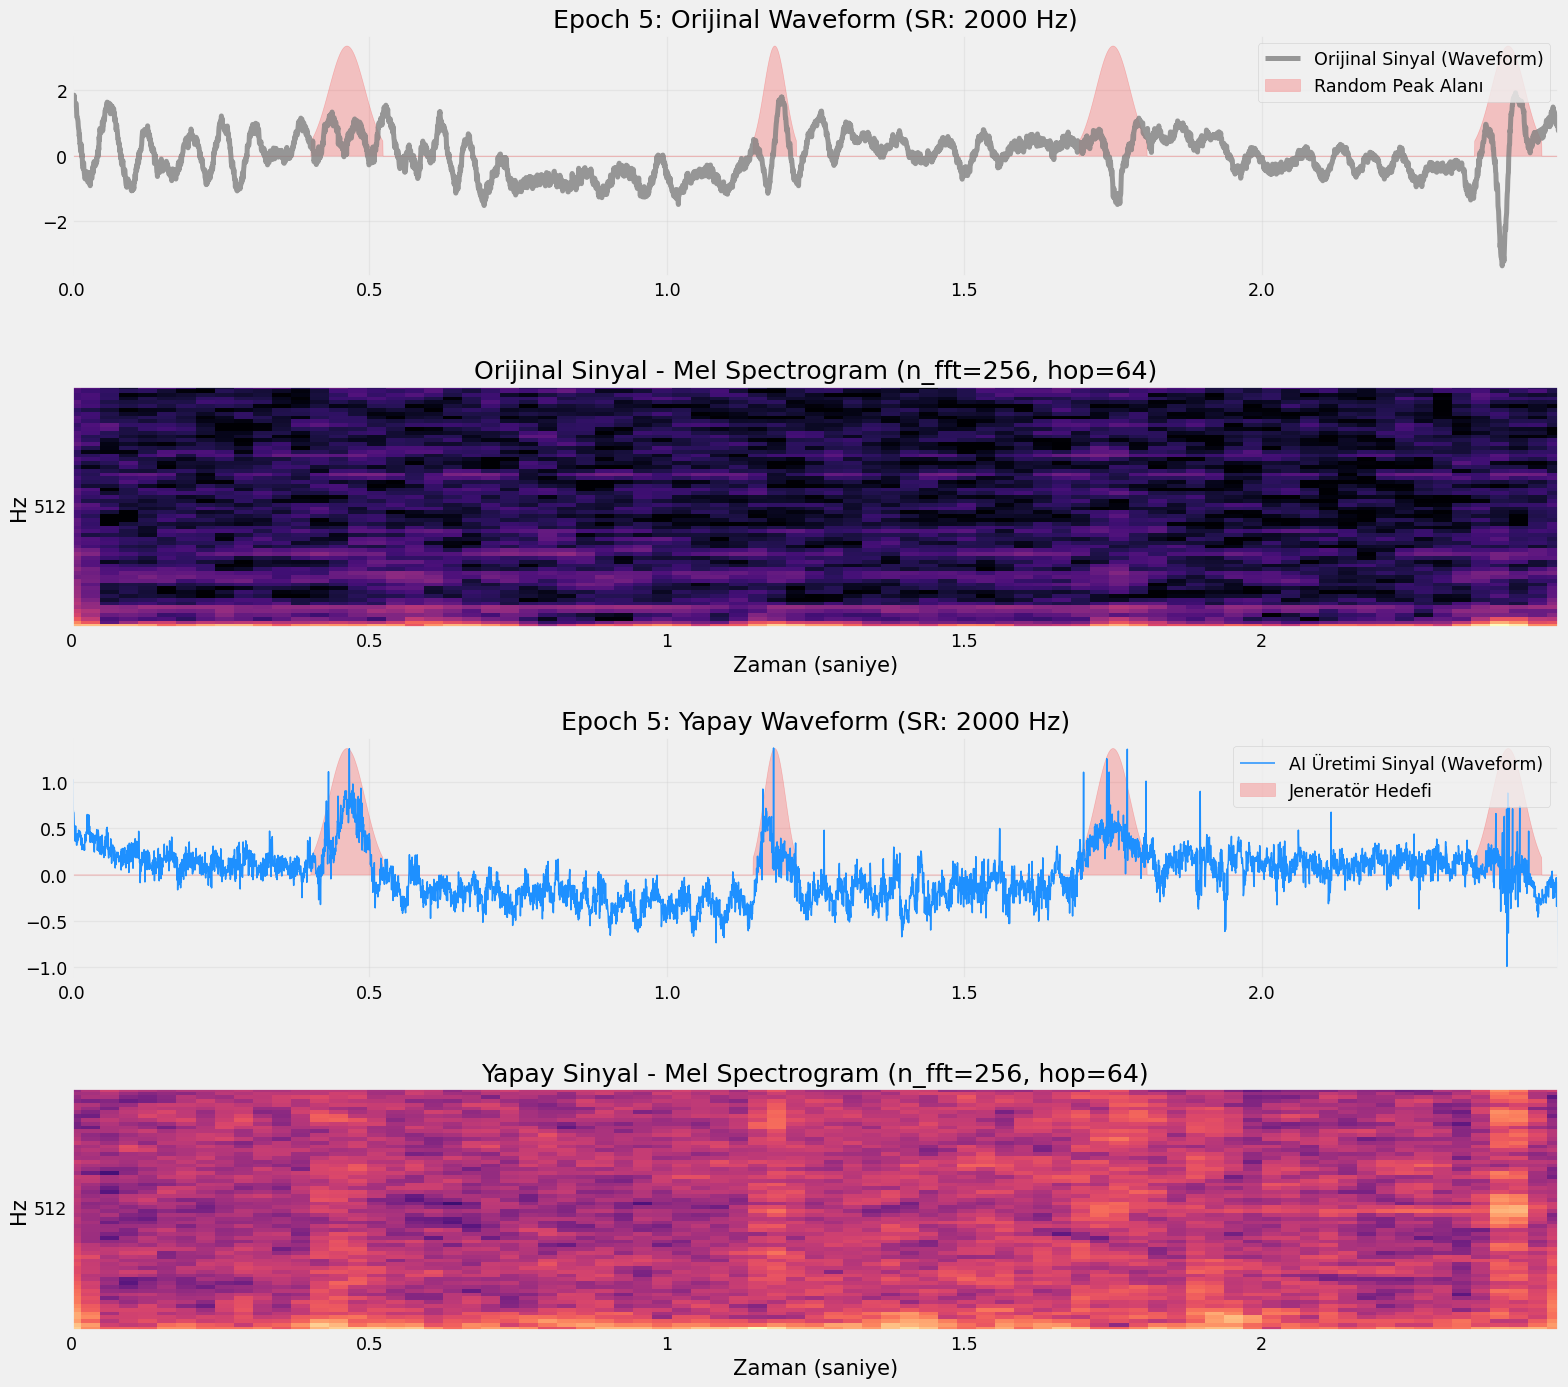

💾 Epoch 5 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 6 BAŞLADI ---
Epoch 6 | Step 428/428 | D_Loss: 0.6541 | G_Total: 19.54
Epoch 6 Özet | D_Loss: 0.6584 | G_Total: 20.45 | Rec: 20.41 | Cls: 0.07
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 6 - Rec Loss: 20.41)
--- EPOCH 7 BAŞLADI ---
Epoch 7 | Step 428/428 | D_Loss: 0.6571 | G_Total: 18.56
Epoch 7 Özet | D_Loss: 0.6567 | G_Total: 19.86 | Rec: 19.82 | Cls: 0.06
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 7 - Rec Loss: 19.82)
--- EPOCH 8 BAŞLADI ---
Epoch 8 | Step 428/428 | D_Loss: 0.6535 | G_Total: 17.28
Epoch 8 Özet | D_Loss: 0.6557 | G_Total: 19.51 | Rec: 19.49 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 8 - Rec Loss: 19.49)
--- EPOCH 9 BAŞLADI ---
Epoch 9 | Step 428/428 | D_Loss: 0.6550 | G_Total: 17.30
Epoch 9 Özet | D_Loss: 0.6543 | G_Total: 19.12 | Rec: 19.10 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 9 - Rec Loss: 19.10)
--- EPOCH 10 BAŞLADI ---
Epoch 10 | Step 428/4

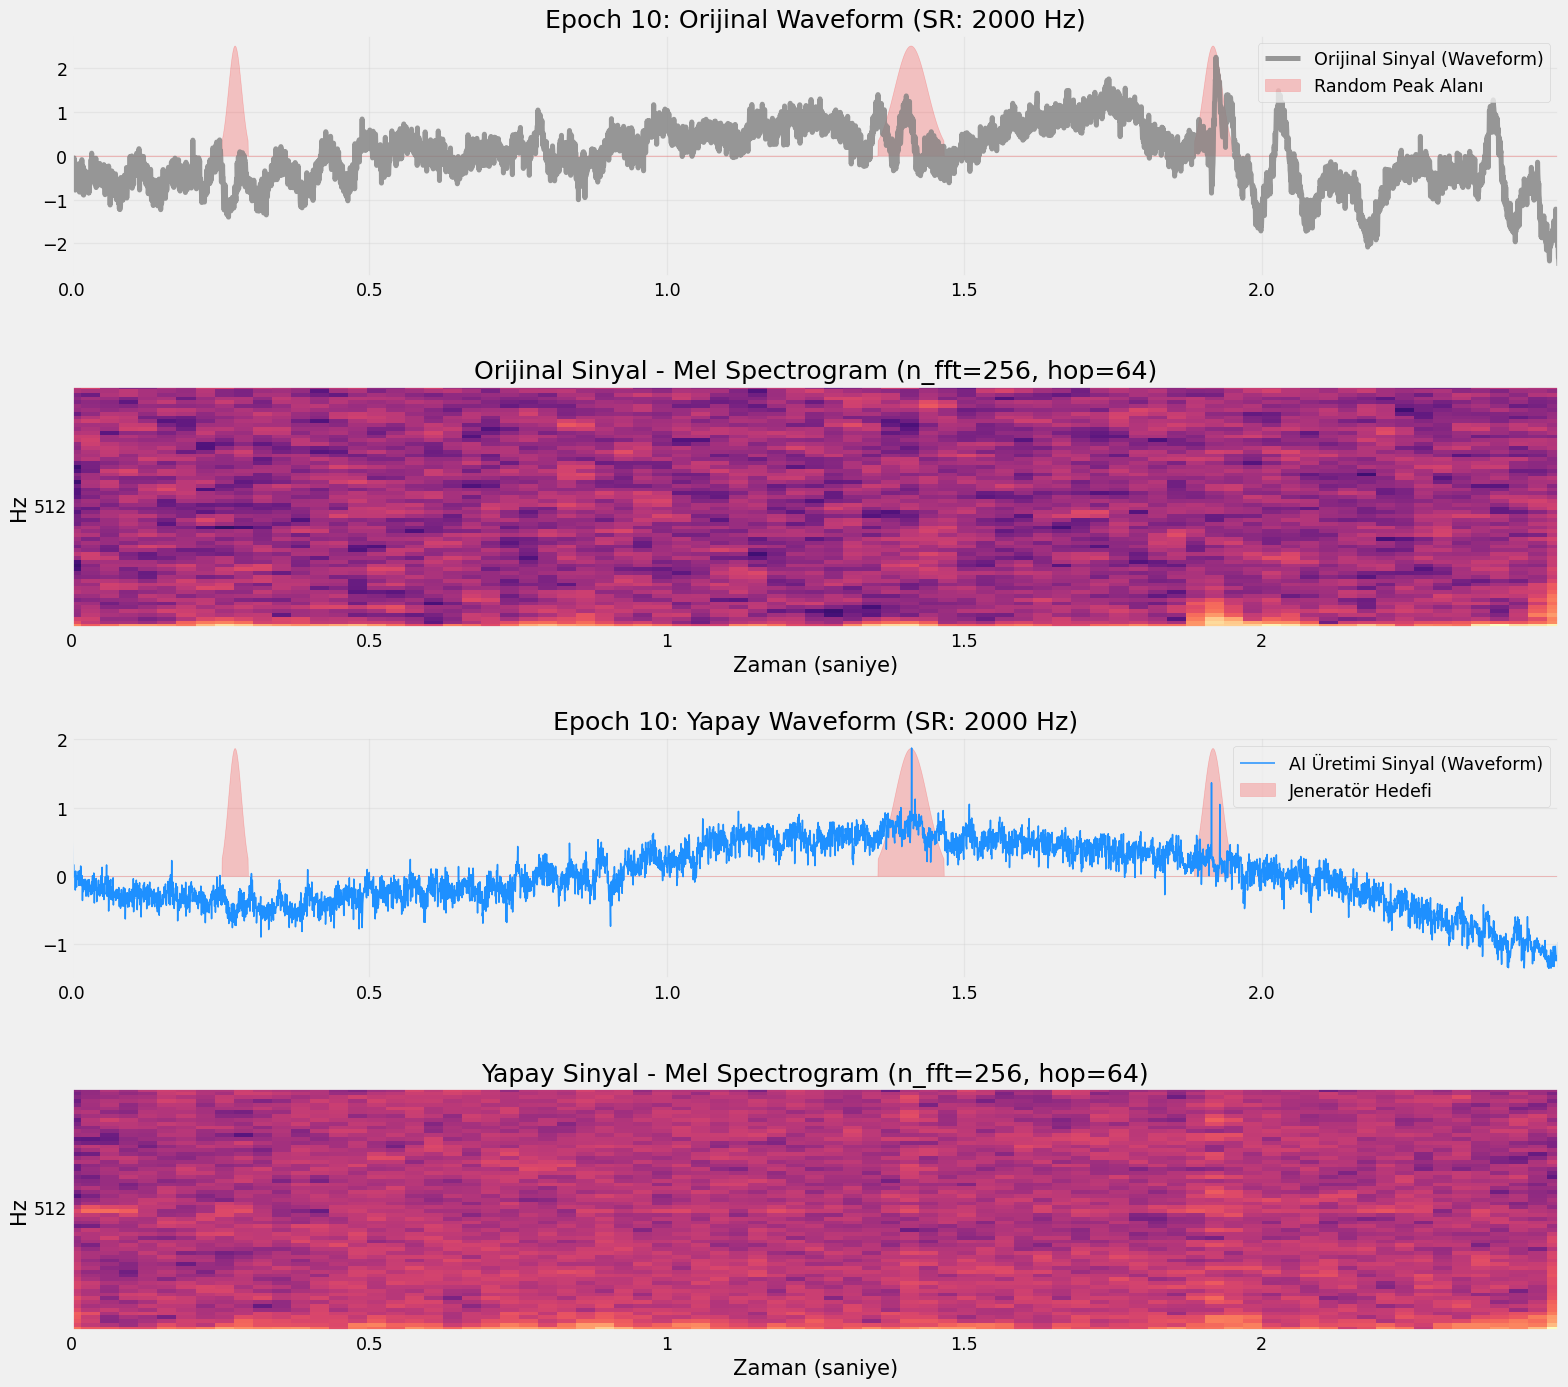

💾 Epoch 10 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 11 BAŞLADI ---
Epoch 11 | Step 428/428 | D_Loss: 0.6527 | G_Total: 15.15
Epoch 11 Özet | D_Loss: 0.6534 | G_Total: 18.73 | Rec: 18.70 | Cls: 0.06
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 11 - Rec Loss: 18.70)
--- EPOCH 12 BAŞLADI ---
Epoch 12 | Step 428/428 | D_Loss: 0.6531 | G_Total: 16.77
Epoch 12 Özet | D_Loss: 0.6529 | G_Total: 18.60 | Rec: 18.58 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 12 - Rec Loss: 18.58)
--- EPOCH 13 BAŞLADI ---
Epoch 13 | Step 428/428 | D_Loss: 0.6522 | G_Total: 16.51
Epoch 13 Özet | D_Loss: 0.6528 | G_Total: 18.41 | Rec: 18.38 | Cls: 0.05
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 13 - Rec Loss: 18.38)
--- EPOCH 14 BAŞLADI ---
Epoch 14 | Step 428/428 | D_Loss: 0.6516 | G_Total: 15.87
Epoch 14 Özet | D_Loss: 0.6523 | G_Total: 18.31 | Rec: 18.29 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 14 - Rec Loss: 18.29)
--- EPOCH 15 BAŞLADI ---
Epoc

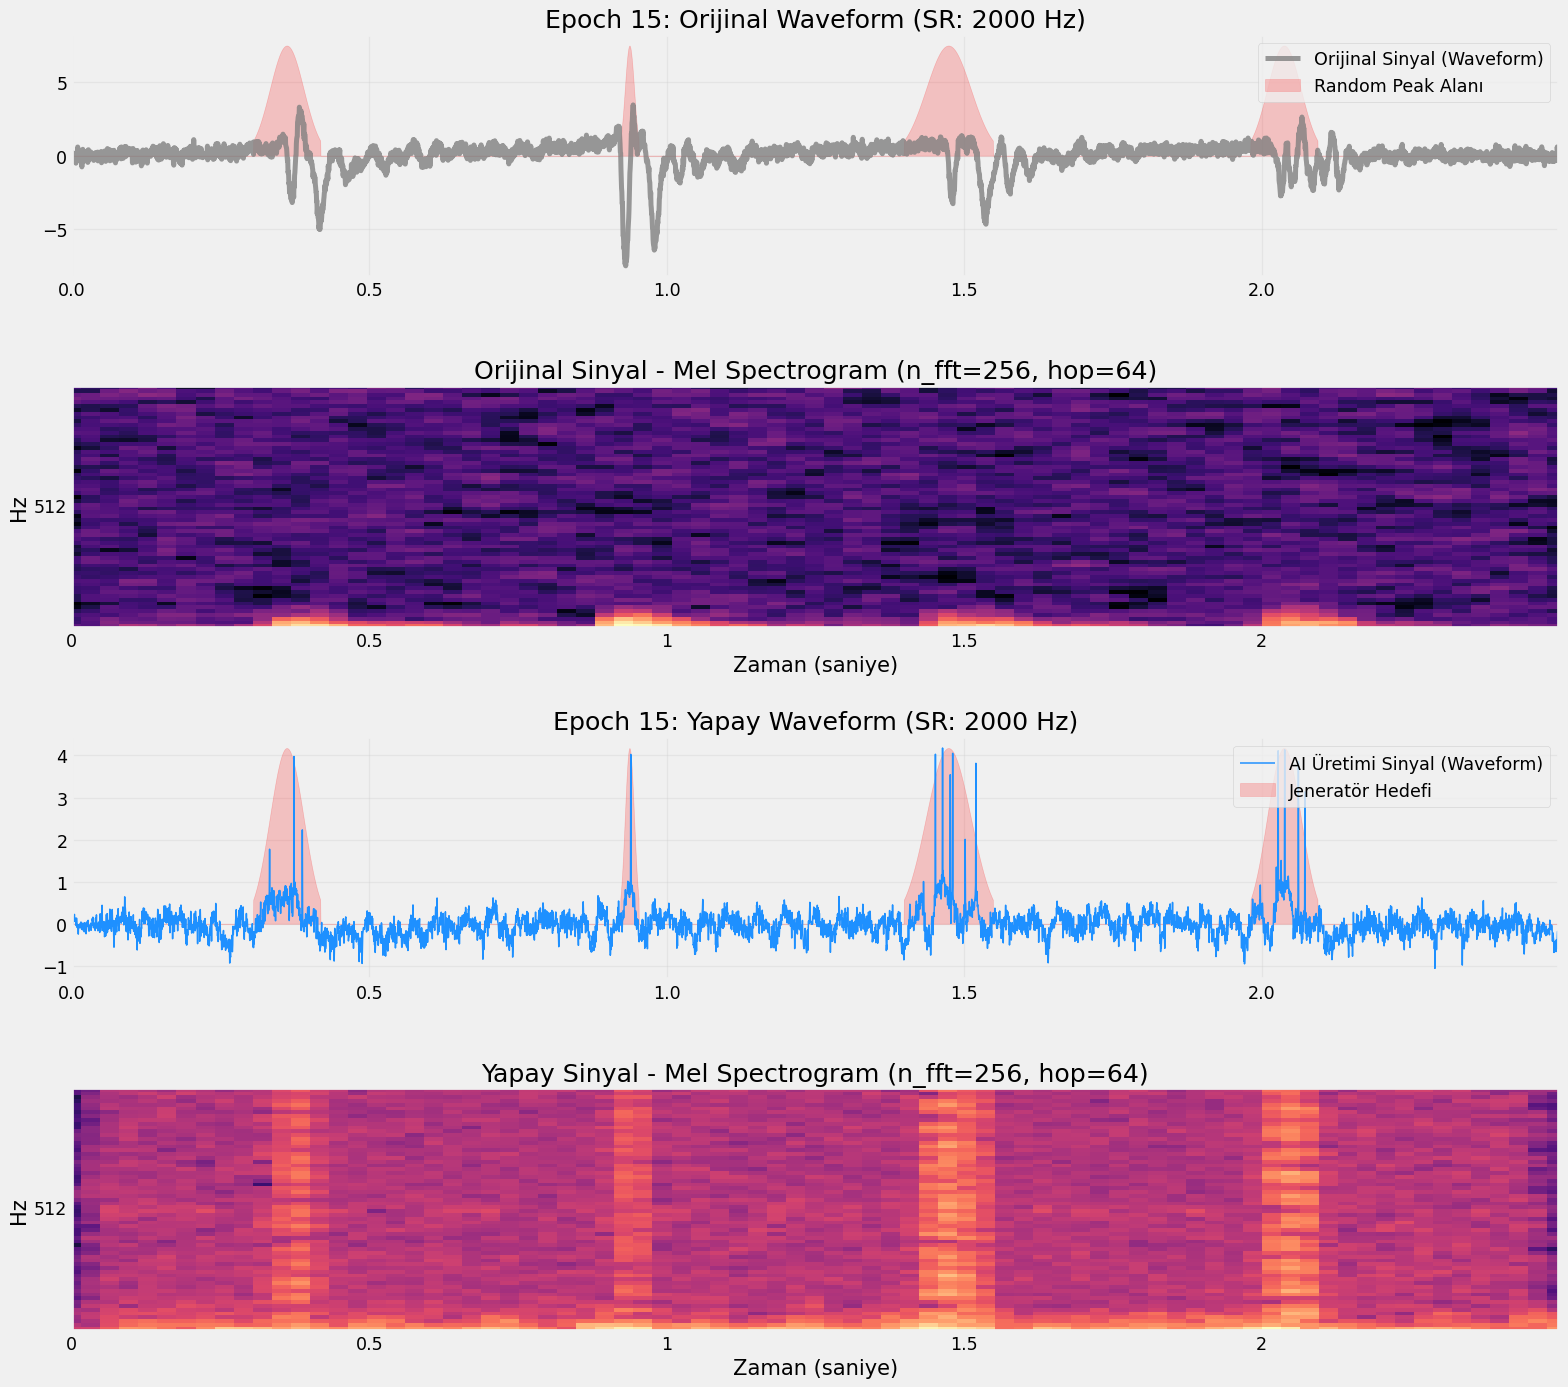

💾 Epoch 15 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 16 BAŞLADI ---
Epoch 16 | Step 428/428 | D_Loss: 0.6522 | G_Total: 16.21
Epoch 16 Özet | D_Loss: 0.6518 | G_Total: 17.96 | Rec: 17.94 | Cls: 0.05
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 16 - Rec Loss: 17.94)
--- EPOCH 17 BAŞLADI ---
Epoch 17 | Step 428/428 | D_Loss: 0.6512 | G_Total: 15.78
Epoch 17 Özet | D_Loss: 0.6517 | G_Total: 17.84 | Rec: 17.82 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 17 - Rec Loss: 17.82)
--- EPOCH 18 BAŞLADI ---
Epoch 18 | Step 428/428 | D_Loss: 0.6511 | G_Total: 16.73
Epoch 18 Özet | D_Loss: 0.6516 | G_Total: 17.70 | Rec: 17.69 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 18 - Rec Loss: 17.69)
--- EPOCH 19 BAŞLADI ---
Epoch 19 | Step 428/428 | D_Loss: 0.6515 | G_Total: 15.46
Epoch 19 Özet | D_Loss: 0.6515 | G_Total: 17.62 | Rec: 17.61 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 19 - Rec Loss: 17.61)
--- EPOCH 20 BAŞLADI ---
Epoc

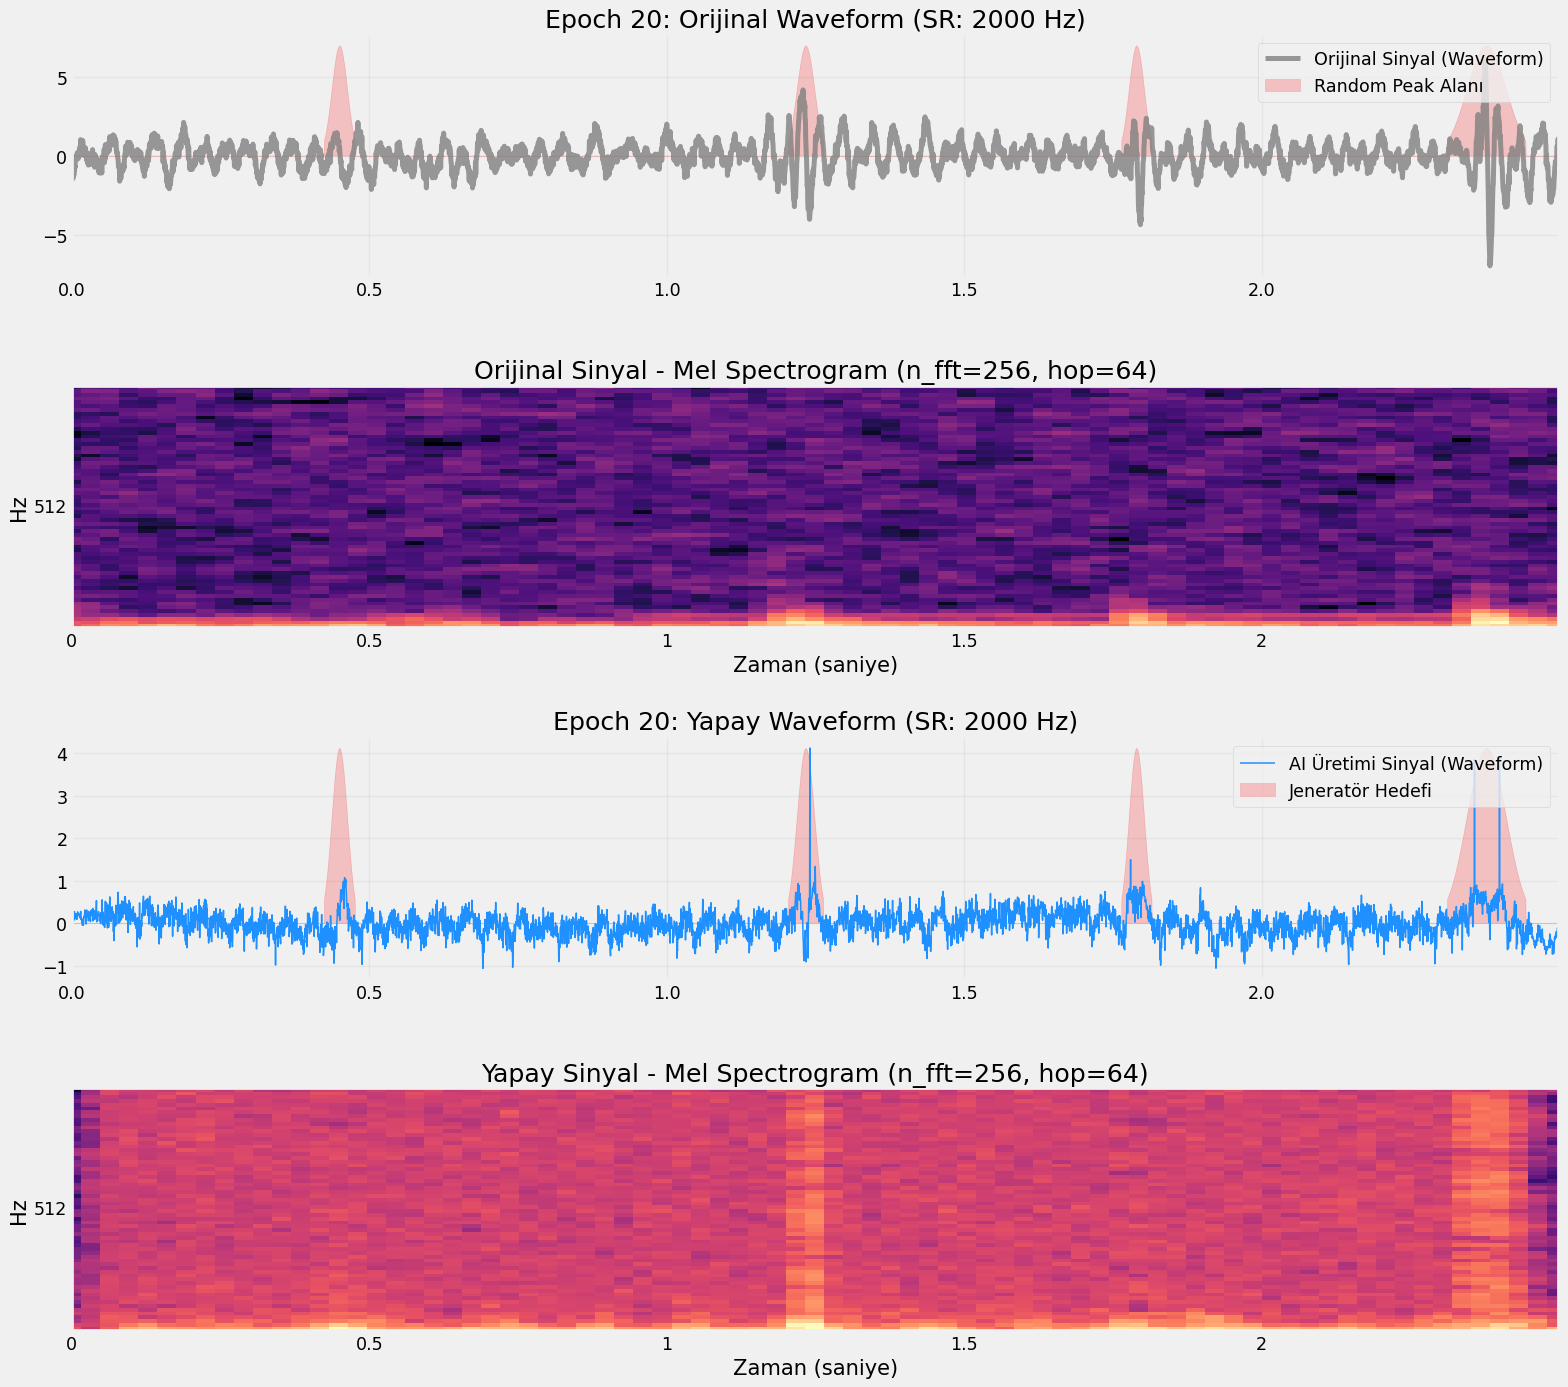

💾 Epoch 20 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 21 BAŞLADI ---
Epoch 21 | Step 428/428 | D_Loss: 0.6514 | G_Total: 16.93
Epoch 21 Özet | D_Loss: 0.6517 | G_Total: 17.42 | Rec: 17.39 | Cls: 0.06
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 21 - Rec Loss: 17.39)
--- EPOCH 22 BAŞLADI ---
Epoch 22 | Step 428/428 | D_Loss: 0.6509 | G_Total: 15.86
Epoch 22 Özet | D_Loss: 0.6511 | G_Total: 17.24 | Rec: 17.22 | Cls: 0.05
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 22 - Rec Loss: 17.22)
--- EPOCH 23 BAŞLADI ---
Epoch 23 | Step 428/428 | D_Loss: 0.6509 | G_Total: 15.82
Epoch 23 Özet | D_Loss: 0.6510 | G_Total: 17.02 | Rec: 17.00 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 23 - Rec Loss: 17.00)
--- EPOCH 24 BAŞLADI ---
Epoch 24 | Step 428/428 | D_Loss: 0.6507 | G_Total: 16.86
Epoch 24 Özet | D_Loss: 0.6509 | G_Total: 16.88 | Rec: 16.86 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 24 - Rec Loss: 16.86)
--- EPOCH 25 BAŞLADI ---
Epoc

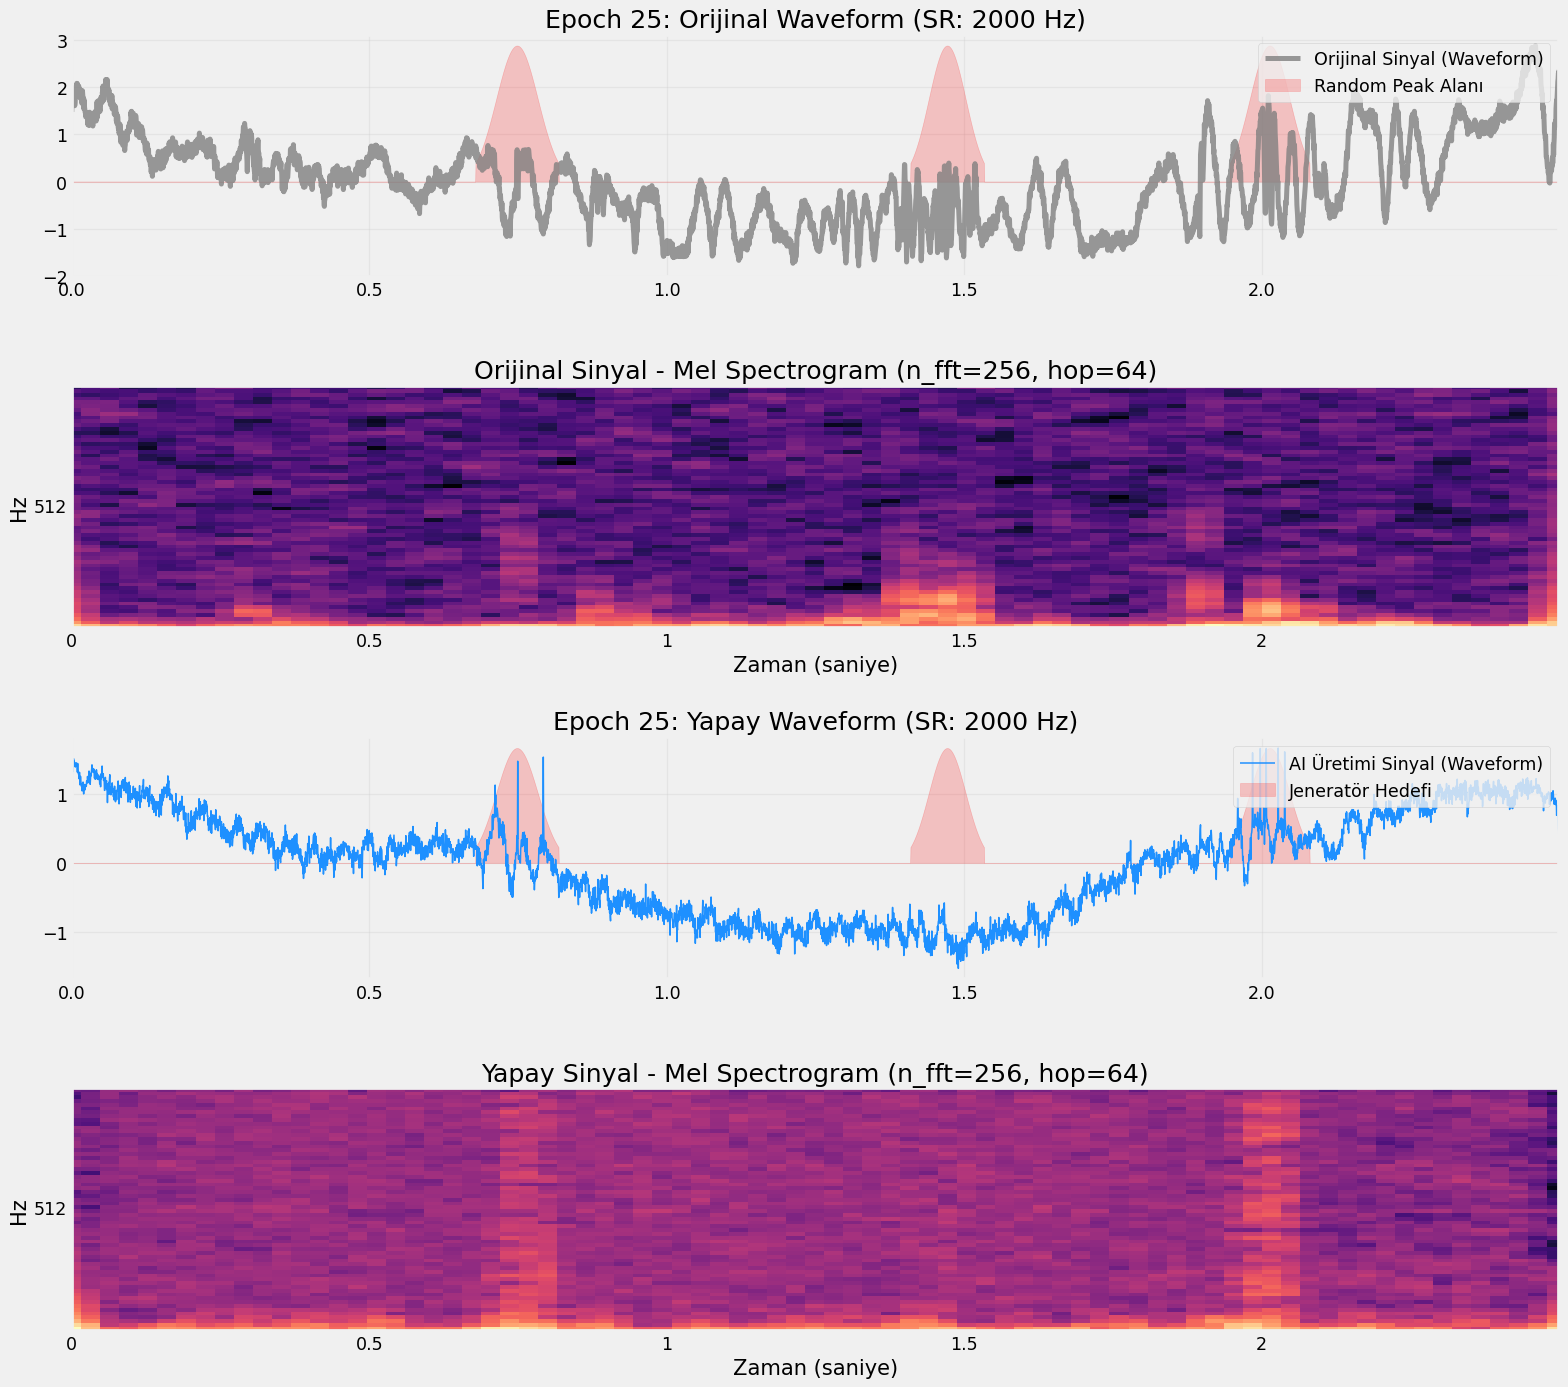

💾 Epoch 25 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 26 BAŞLADI ---
Epoch 26 | Step 428/428 | D_Loss: 0.6507 | G_Total: 14.77
Epoch 26 Özet | D_Loss: 0.6508 | G_Total: 16.66 | Rec: 16.64 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 26 - Rec Loss: 16.64)
--- EPOCH 27 BAŞLADI ---
Epoch 27 | Step 428/428 | D_Loss: 0.6511 | G_Total: 15.24
Epoch 27 Özet | D_Loss: 0.6508 | G_Total: 16.58 | Rec: 16.56 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 27 - Rec Loss: 16.56)
--- EPOCH 28 BAŞLADI ---
Epoch 28 | Step 428/428 | D_Loss: 0.6505 | G_Total: 15.82
Epoch 28 Özet | D_Loss: 0.6507 | G_Total: 16.61 | Rec: 16.59 | Cls: 0.04
--- EPOCH 29 BAŞLADI ---
Epoch 29 | Step 428/428 | D_Loss: 0.6505 | G_Total: 14.57
Epoch 29 Özet | D_Loss: 0.6507 | G_Total: 16.44 | Rec: 16.42 | Cls: 0.05
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 29 - Rec Loss: 16.42)
--- EPOCH 30 BAŞLADI ---
Epoch 30 | Step 428/428 | D_Loss: 0.6516 | G_Total: 16.40
Epoch 30 Özet | D_

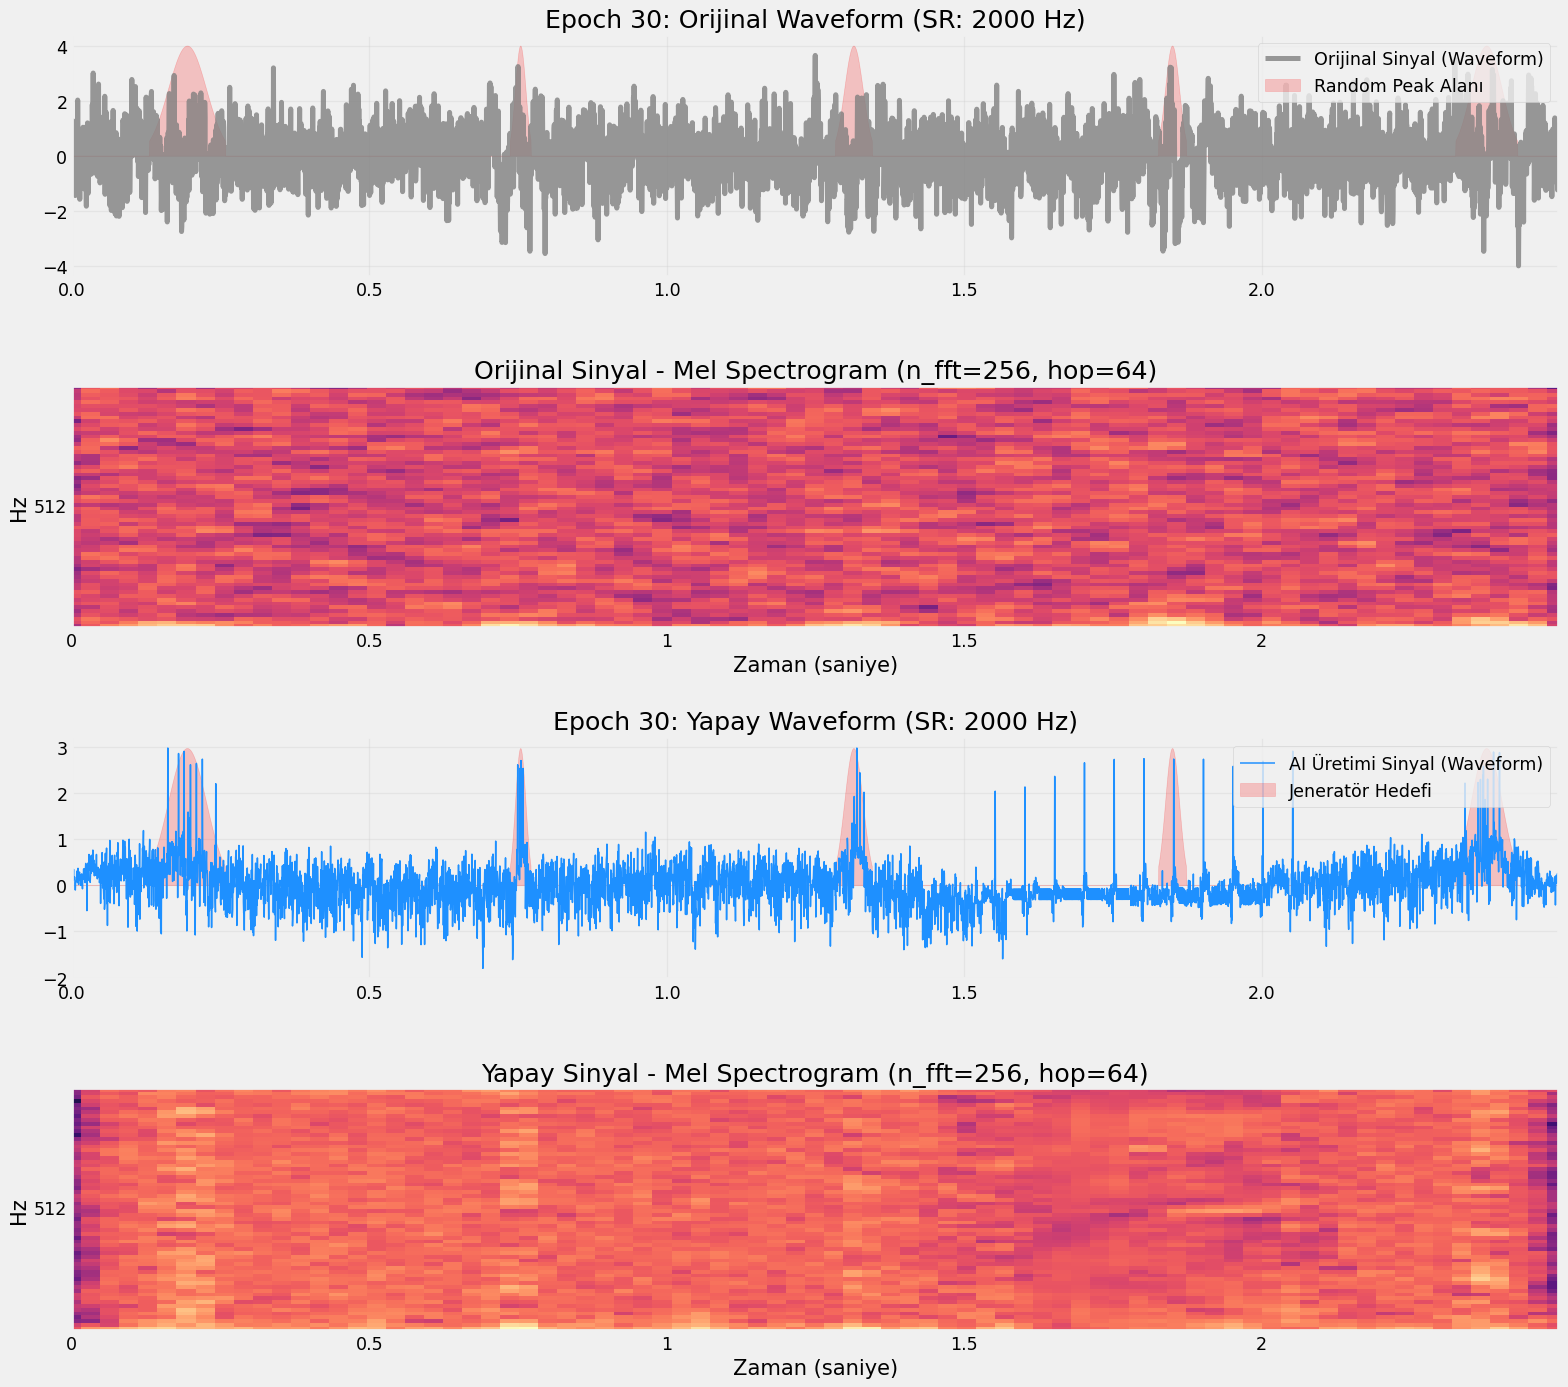

💾 Epoch 30 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 31 BAŞLADI ---
Epoch 31 | Step 428/428 | D_Loss: 0.6508 | G_Total: 14.30
Epoch 31 Özet | D_Loss: 0.6507 | G_Total: 16.52 | Rec: 16.50 | Cls: 0.04
--- EPOCH 32 BAŞLADI ---
Epoch 32 | Step 428/428 | D_Loss: 0.6507 | G_Total: 14.48
Epoch 32 Özet | D_Loss: 0.6506 | G_Total: 16.37 | Rec: 16.36 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 32 - Rec Loss: 16.36)
--- EPOCH 33 BAŞLADI ---
Epoch 33 | Step 428/428 | D_Loss: 0.6508 | G_Total: 14.73
Epoch 33 Özet | D_Loss: 0.6506 | G_Total: 16.23 | Rec: 16.21 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 33 - Rec Loss: 16.21)
--- EPOCH 34 BAŞLADI ---
Epoch 34 | Step 428/428 | D_Loss: 0.6504 | G_Total: 13.91
Epoch 34 Özet | D_Loss: 0.6505 | G_Total: 16.16 | Rec: 16.14 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 34 - Rec Loss: 16.14)
--- EPOCH 35 BAŞLADI ---
Epoch 35 | Step 428/428 | D_Loss: 0.6504 | G_Total: 15.49
Epoch 35 Özet | D_

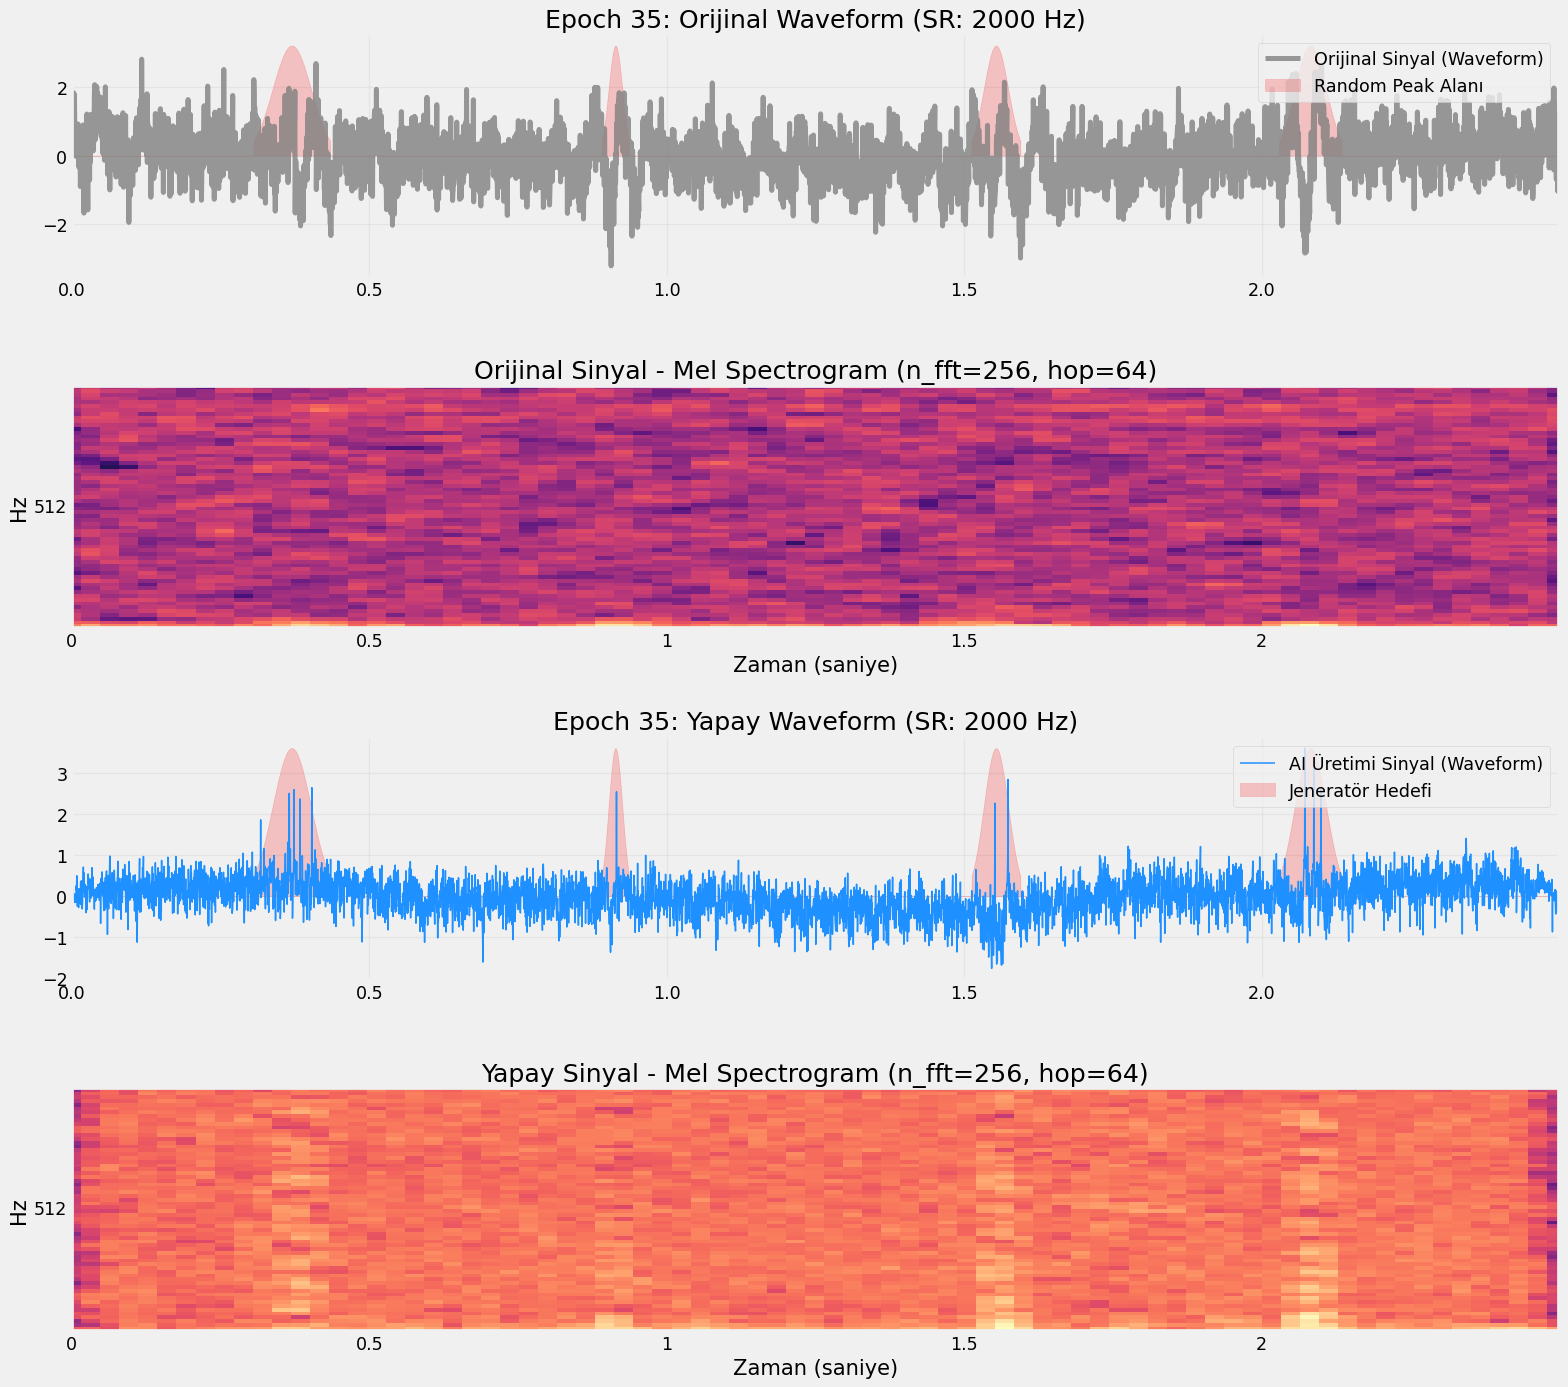

💾 Epoch 35 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 36 BAŞLADI ---
Epoch 36 | Step 428/428 | D_Loss: 0.6505 | G_Total: 15.72
Epoch 36 Özet | D_Loss: 0.6505 | G_Total: 16.06 | Rec: 16.04 | Cls: 0.05
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 36 - Rec Loss: 16.04)
--- EPOCH 37 BAŞLADI ---
Epoch 37 | Step 428/428 | D_Loss: 0.6504 | G_Total: 14.28
Epoch 37 Özet | D_Loss: 0.6505 | G_Total: 15.95 | Rec: 15.93 | Cls: 0.05
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 37 - Rec Loss: 15.93)
--- EPOCH 38 BAŞLADI ---
Epoch 38 | Step 428/428 | D_Loss: 0.6508 | G_Total: 13.85
Epoch 38 Özet | D_Loss: 0.6505 | G_Total: 16.03 | Rec: 16.01 | Cls: 0.04
--- EPOCH 39 BAŞLADI ---
Epoch 39 | Step 428/428 | D_Loss: 0.6508 | G_Total: 14.46
Epoch 39 Özet | D_Loss: 0.6505 | G_Total: 15.86 | Rec: 15.84 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 39 - Rec Loss: 15.84)
--- EPOCH 40 BAŞLADI ---
Epoch 40 | Step 428/428 | D_Loss: 0.6506 | G_Total: 14.91
Epoch 40 Özet | D_

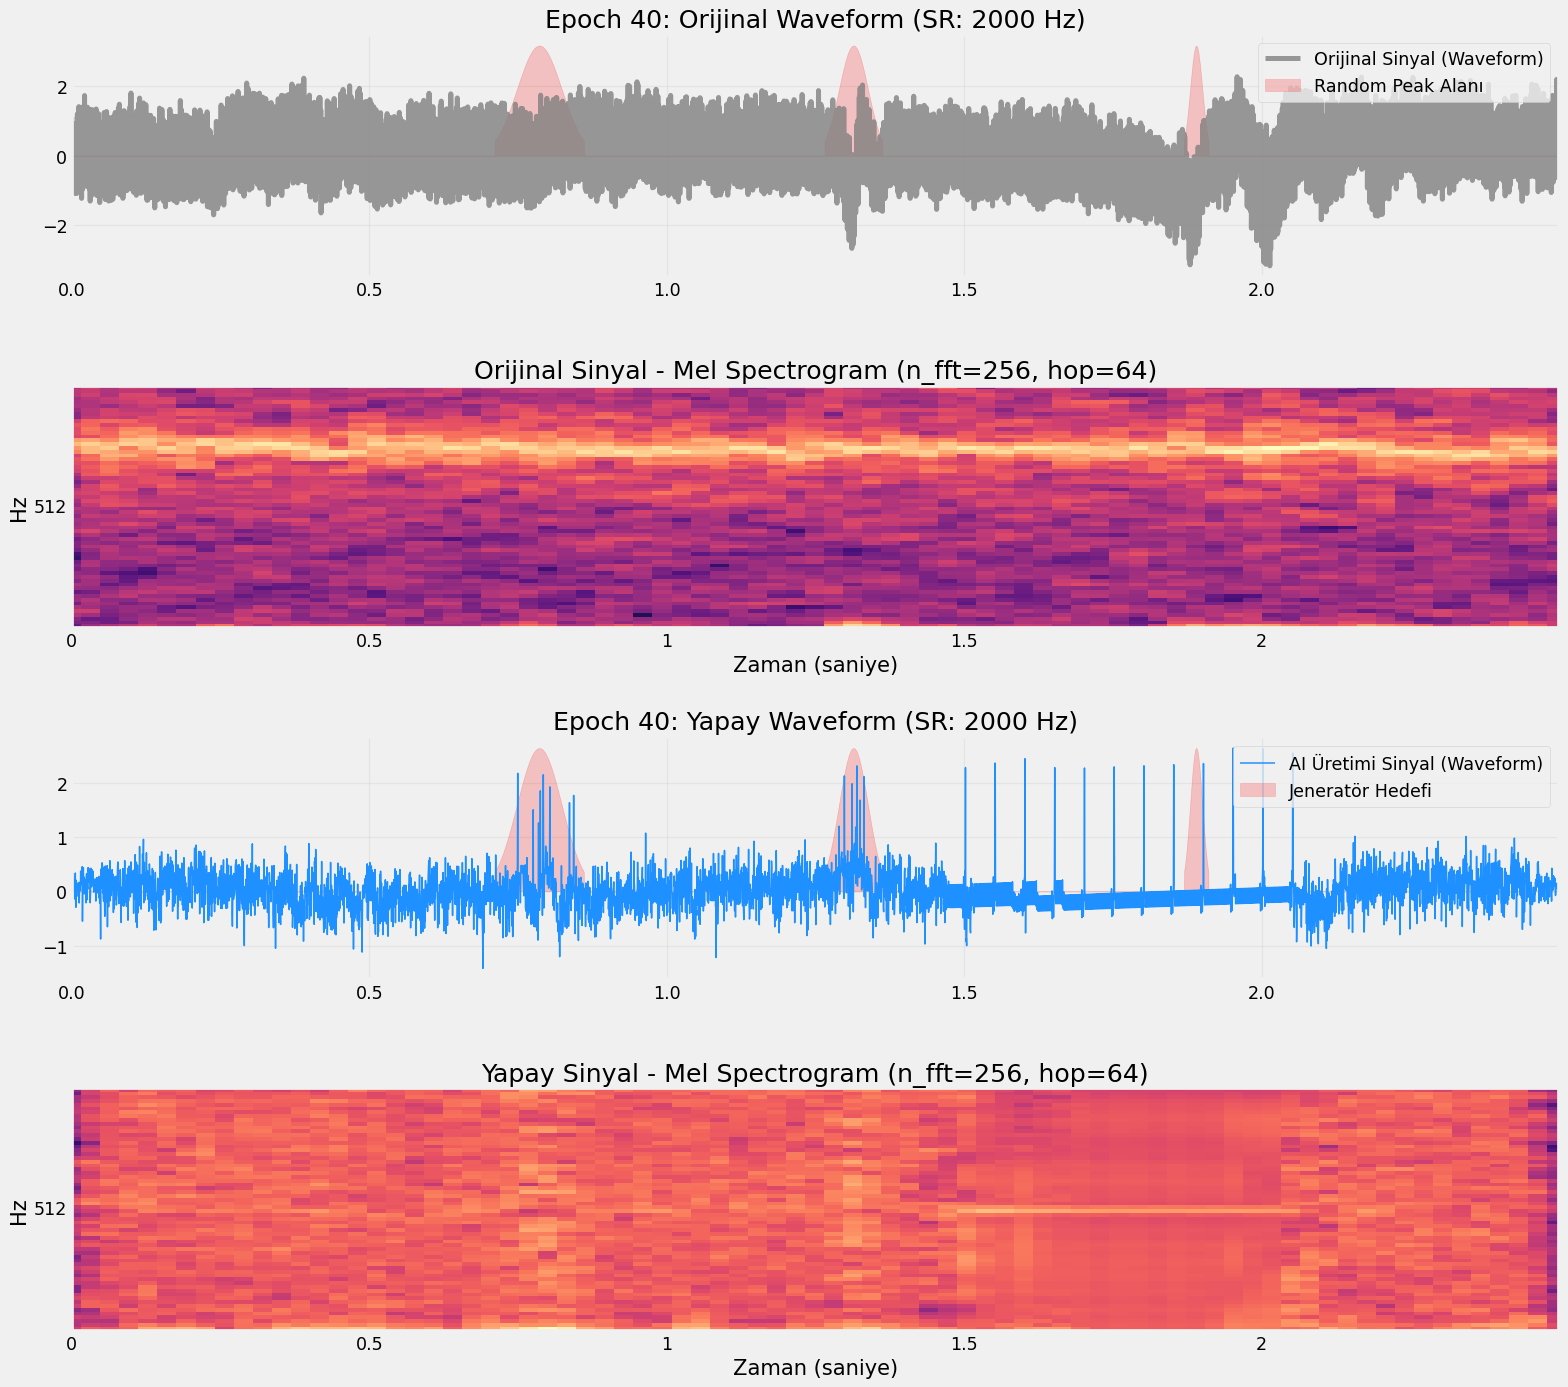

💾 Epoch 40 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 41 BAŞLADI ---
Epoch 41 | Step 428/428 | D_Loss: 0.6504 | G_Total: 14.30
Epoch 41 Özet | D_Loss: 0.6504 | G_Total: 15.75 | Rec: 15.73 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 41 - Rec Loss: 15.73)
--- EPOCH 42 BAŞLADI ---
Epoch 42 | Step 428/428 | D_Loss: 0.6506 | G_Total: 14.19
Epoch 42 Özet | D_Loss: 0.6504 | G_Total: 15.69 | Rec: 15.68 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 42 - Rec Loss: 15.68)
--- EPOCH 43 BAŞLADI ---
Epoch 43 | Step 428/428 | D_Loss: 0.6503 | G_Total: 15.34
Epoch 43 Özet | D_Loss: 0.6504 | G_Total: 15.66 | Rec: 15.64 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 43 - Rec Loss: 15.64)
--- EPOCH 44 BAŞLADI ---
Epoch 44 | Step 428/428 | D_Loss: 0.6504 | G_Total: 15.03
Epoch 44 Özet | D_Loss: 0.6504 | G_Total: 15.54 | Rec: 15.53 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 44 - Rec Loss: 15.53)
--- EPOCH 45 BAŞLADI ---
Epoc

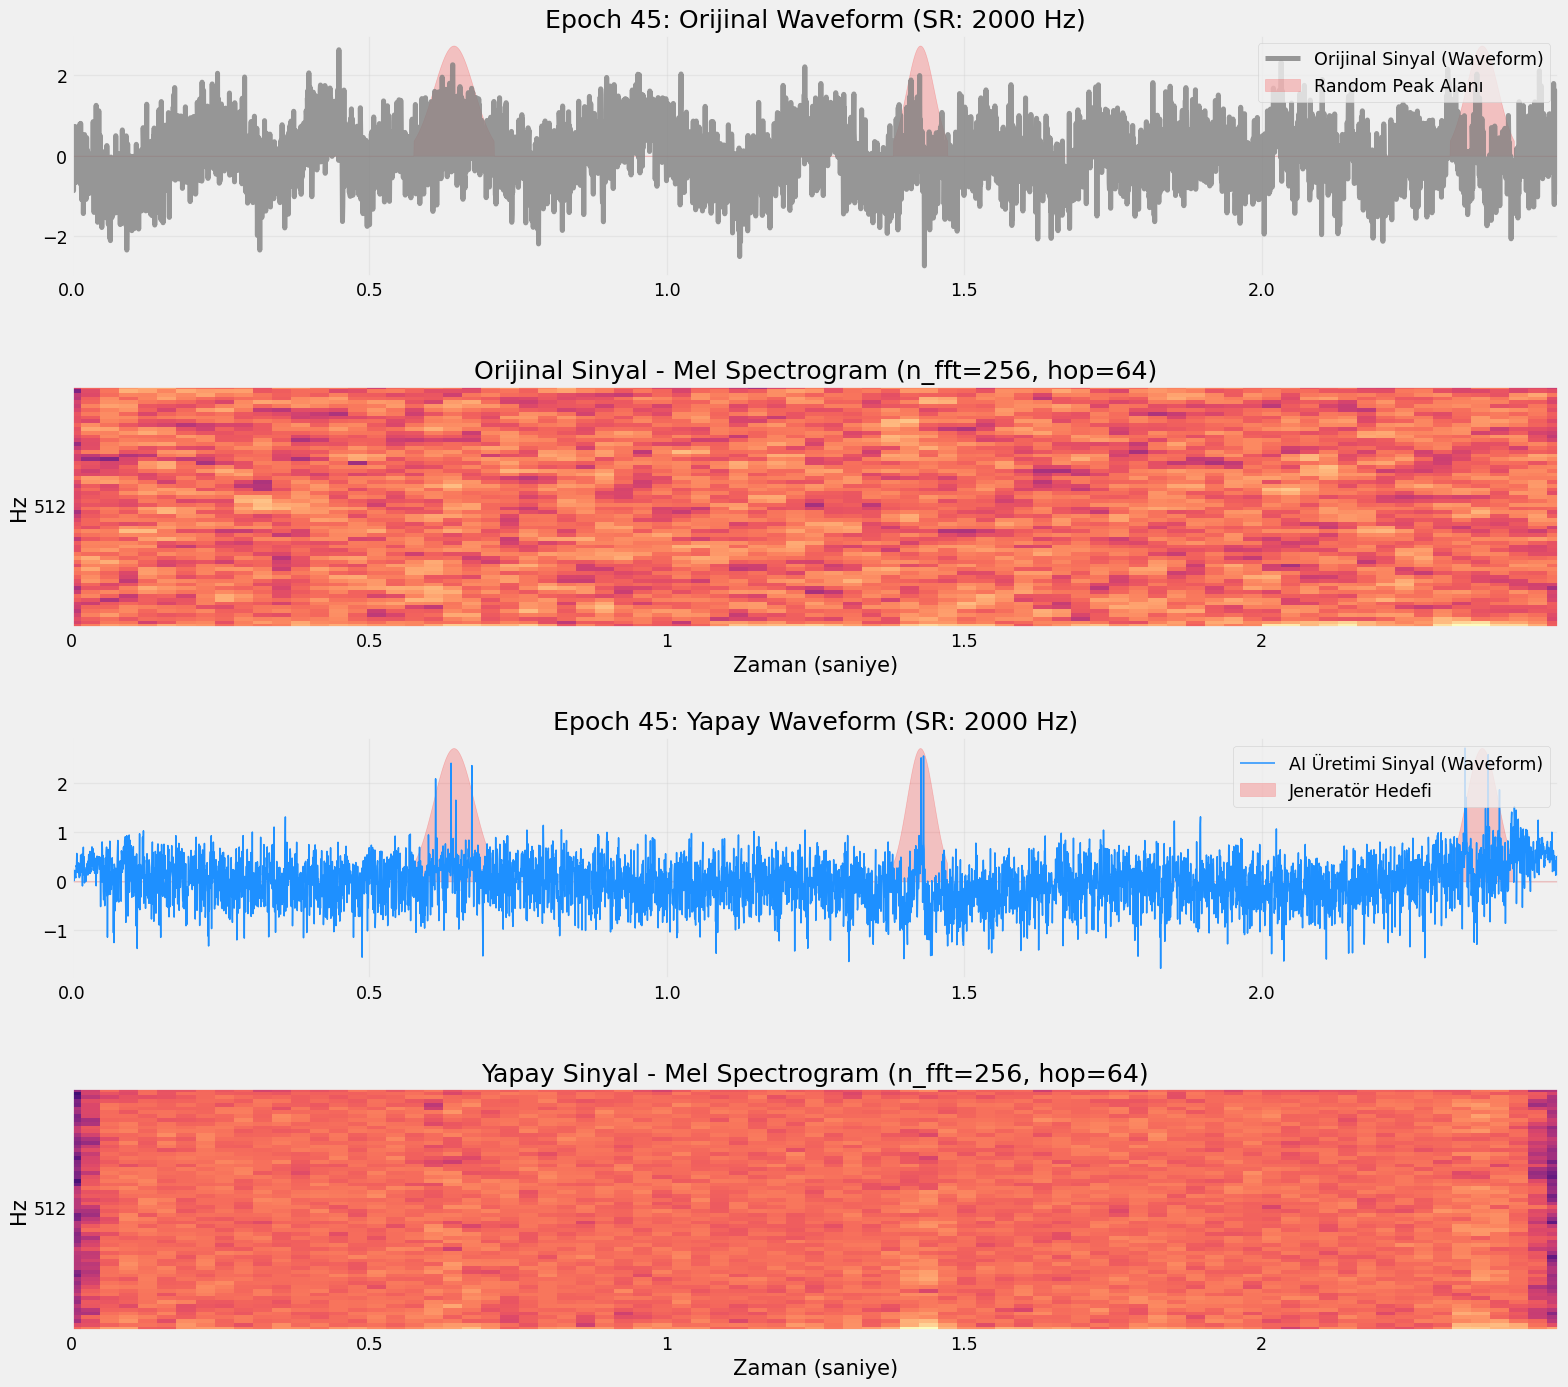

💾 Epoch 45 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 46 BAŞLADI ---
Epoch 46 | Step 428/428 | D_Loss: 0.6503 | G_Total: 15.67
Epoch 46 Özet | D_Loss: 0.6504 | G_Total: 15.63 | Rec: 15.61 | Cls: 0.04
--- EPOCH 47 BAŞLADI ---
Epoch 47 | Step 428/428 | D_Loss: 0.6505 | G_Total: 14.53
Epoch 47 Özet | D_Loss: 0.6504 | G_Total: 15.54 | Rec: 15.52 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 47 - Rec Loss: 15.52)
--- EPOCH 48 BAŞLADI ---
Epoch 48 | Step 428/428 | D_Loss: 0.6505 | G_Total: 14.20
Epoch 48 Özet | D_Loss: 0.6504 | G_Total: 15.42 | Rec: 15.40 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 48 - Rec Loss: 15.40)
--- EPOCH 49 BAŞLADI ---
Epoch 49 | Step 428/428 | D_Loss: 0.6504 | G_Total: 13.35
Epoch 49 Özet | D_Loss: 0.6504 | G_Total: 15.40 | Rec: 15.38 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 49 - Rec Loss: 15.38)
--- EPOCH 50 BAŞLADI ---
Epoch 50 | Step 428/428 | D_Loss: 0.6503 | G_Total: 14.16
Epoch 50 Özet | D_

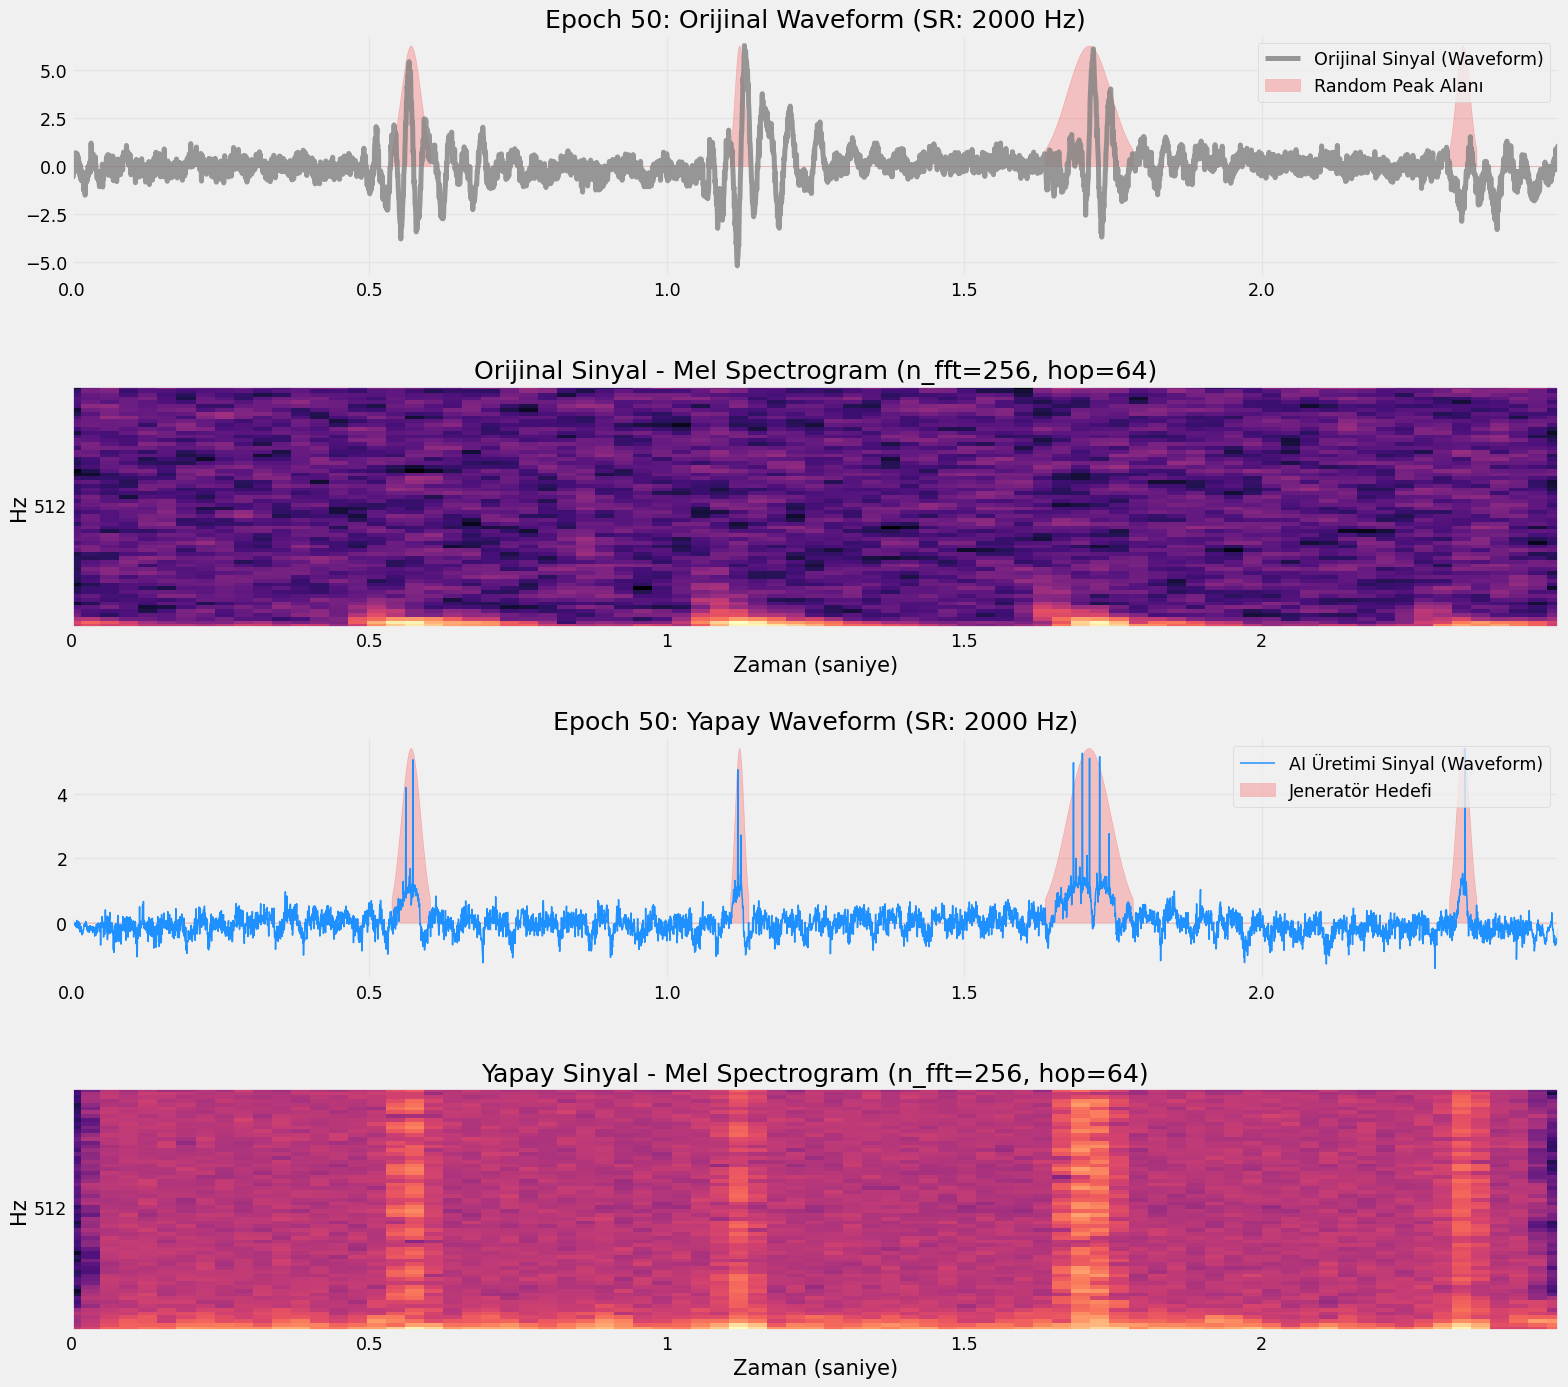

💾 Epoch 50 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 51 BAŞLADI ---
Epoch 51 | Step 428/428 | D_Loss: 0.6505 | G_Total: 14.02
Epoch 51 Özet | D_Loss: 0.6503 | G_Total: 15.37 | Rec: 15.35 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 51 - Rec Loss: 15.35)
--- EPOCH 52 BAŞLADI ---
Epoch 52 | Step 428/428 | D_Loss: 0.6506 | G_Total: 14.45
Epoch 52 Özet | D_Loss: 0.6503 | G_Total: 15.25 | Rec: 15.23 | Cls: 0.04
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 52 - Rec Loss: 15.23)
--- EPOCH 53 BAŞLADI ---
Epoch 53 | Step 428/428 | D_Loss: 0.6503 | G_Total: 13.65
Epoch 53 Özet | D_Loss: 0.6503 | G_Total: 15.32 | Rec: 15.30 | Cls: 0.04
--- EPOCH 54 BAŞLADI ---
Epoch 54 | Step 428/428 | D_Loss: 0.6503 | G_Total: 13.72
Epoch 54 Özet | D_Loss: 0.6503 | G_Total: 15.21 | Rec: 15.20 | Cls: 0.03
🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: 54 - Rec Loss: 15.20)
--- EPOCH 55 BAŞLADI ---
Epoch 55 | Step 244/428 | D_Loss: 0.6503 | G_Total: 13.39

KeyboardInterrupt: 

In [12]:
import time
import tensorflow as tf
import os

EPOCHS = 500
best_rec_loss = float('inf') # G_Loss yerine Fiziksel Kaybı (L_rec) takip ediyoruz
best_epoch_num = 0

# Weights klasörünün var olduğundan emin ol (Epoch 5'te çökmemesi için)
weights_dir = os.path.join(MODEL_FOLDER, "weights")
os.makedirs(weights_dir, exist_ok=True)

for epoch in range(EPOCHS):
    start = time.time()
    
    # Tüm metrikler için liste açıyoruz
    epoch_d_loss = []
    epoch_g_loss = []
    epoch_rec_loss = []
    epoch_cls_loss = []
    
    total_steps = len(train_seq)
    print(f"--- EPOCH {epoch+1} BAŞLADI ---")
    
    for step in range(total_steps):
        batch_data, _ = train_seq[step] 
        real_sigs = tf.convert_to_tensor(batch_data[:, :, 0:1], dtype=tf.float32)
        peaks = tf.convert_to_tensor(batch_data[:, :, 1:2], dtype=tf.float32)
        enc_masks = tf.convert_to_tensor(batch_data[:, :, 2:3], dtype=tf.float32)
        d_l, g_l, l_rec, l_cls = train_step(real_sigs, peaks, enc_masks)
        
        epoch_d_loss.append(d_l)
        epoch_g_loss.append(g_l)
        epoch_rec_loss.append(l_rec)
        epoch_cls_loss.append(l_cls)
        
        print(f"Epoch {epoch+1} | Step {step+1}/{total_steps} | D_Loss: {d_l:.4f} | G_Total: {g_l:.2f}", end='\r', flush=True)

    # Epoch ortalamaları (Artık tüm metrikler gerçek ortalama)
    avg_d_loss = tf.reduce_mean(epoch_d_loss).numpy()
    avg_g_loss = tf.reduce_mean(epoch_g_loss).numpy()
    avg_rec_loss = tf.reduce_mean(epoch_rec_loss).numpy()
    avg_cls_loss = tf.reduce_mean(epoch_cls_loss).numpy()
    
    print(f"\nEpoch {epoch+1} Özet | D_Loss: {avg_d_loss:.4f} | G_Total: {avg_g_loss:.2f} | Rec: {avg_rec_loss:.2f} | Cls: {avg_cls_loss:.2f}")
    
    # BEST EPOCH TAKİBİ (Fiziksel Kaliteye Göre)
    if avg_rec_loss < best_rec_loss:
        best_rec_loss = avg_rec_loss
        best_epoch_num = epoch + 1
        print(f"🌟 Yeni En İyi Fiziksel Başarı! (Best Epoch şu an: {best_epoch_num} - Rec Loss: {best_rec_loss:.2f})")

    # HER 5 EPOCH'TA BİR: ÇİZİM YAP VE AĞIRLIKLARI KAYDET
    if (epoch + 1) % 5 == 0:
        # 1. Çizimi model klasörüne kaydet
        visualize_epoch_results(epoch, encoder, generator, train_seq, MODEL_FOLDER)
        
        # 2. Manuel seçim yapabilmen için ağırlıkları (weights) kaydet
        enc_weight_path = os.path.join(weights_dir, f"encoder_epoch_{epoch+1}.weights.h5")
        gen_weight_path = os.path.join(weights_dir, f"generator_epoch_{epoch+1}.weights.h5")
        
        encoder.save_weights(enc_weight_path)
        generator.save_weights(gen_weight_path)
        print(f"💾 Epoch {epoch+1} görselleri ve ağırlıkları başarıyla kaydedildi.")

print(f"\n✅ EĞİTİM BİTTİ! Matematiksel Olarak En İyi Epoch: {best_epoch_num}")
print(f"Tüm ağırlıklar ve görseller '{MODEL_FOLDER}' klasöründe incelenmeyi bekliyor.")